# Berlin neighborhood clustering

This notebook starts from the engineered neighborhood feature table and explores unsupervised clustering strategies.

Goals:

- test whether the feature space produces meaningful neighborhood clusters
- evaluate separation quality using clustering KPIs
- inspect whether a clear inner vs outer Berlin split emerges
- prepare for future user-weighted similarity scenarios

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root added to sys.path:", PROJECT_ROOT)

Project root added to sys.path: /Users/pino/webeet/layered-district-labeling/neighborhood_clustering


In [2]:
from pathlib import Path
import os

from dotenv import load_dotenv

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd

from shapely import wkb
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

from src.clustering import (
    evaluate_kmeans,
    compute_kmeans_elbow,
    interpret_kmeans_solution,
)

from src.weighting import (
    apply_group_weights,
    weight_stability_analysis,
    run_group_weighted_kmeans_diagnostics,
)

from src.scoring import rank_clusters_for_preference

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

## Section A. Data preparation

### Load engineered feature table

We start from the final exploration dataset generated in `01_data_exploration.ipynb`.

This table already contains:

- spatial density features
- population-normalized features
- area shares
- proximity features
- accessibility ratio
- selected raw scalar features

In [3]:
data_path = Path("../data/neighborhood_features_exploration.csv")

df = pd.read_csv(data_path, dtype={"neighborhood_id": str})

print("Shape:", df.shape)
display(df.head())

Shape: (96, 87)


,neighborhood_id,neighborhood,district,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
0,0401,Charlottenburg,Charlottenburg-Wilmersdorf,1501.555556,0.013922,0.000000,13.501329,0.849734,5.570478,1.132979,8.308510,0.660904,0.0,0.283245,1.132979,3.87101,7.742021,7.081117,0.944149,9.630319,7.269946,1.132979,7.647606,0.37766,1.982713,1.132979,3201.325644,720.102359,3.682181,0.283245,0.283245,8.780585,2.832447,0.755319,2.265957,0.000000,6.042553,8.308510,0.0,5.948138,2.360372,1.699468,1.605053,7.553191,0.849734,73.832443,0.566489,13892.759605,0.074535,0.005773,0.00000,0.589740,0.183815,0.045954,4.955348,0.620376,322.042804,289.884830,316.220438,286.444421,244.791813,380.812608,246.175464,306.766583,287.287716,46.249897,313.711000,279.028663,238.448888,539.394383,539.383918,358.067683,569.602022,950.097866,660.263775,323.040862,323.040862,321.531893,759.251530,1212.901459,885.261494,836.763893,925.856678,359.337887,195.817547,578.042101,513.063422
1,0406,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,449.875000,0.003415,0.000000,8.876007,0.000000,0.161382,0.000000,0.322764,0.645528,0.0,0.645528,0.000000,0.00000,0.645528,0.322764,0.000000,0.000000,1.452438,0.161382,1.291056,0.00000,0.161382,0.161382,1071.898933,258.211125,0.484146,0.000000,0.161382,0.806910,0.484146,0.000000,0.968292,0.000000,1.291056,0.161382,0.0,0.645528,0.000000,0.484146,0.484146,1.452438,0.000000,1.452438,0.000000,6521.960580,0.013339,0.002981,0.00000,0.457992,0.305328,0.000000,0.000000,0.407104,1041.505855,1336.086514,285.683805,1259.967511,1482.522718,2094.890766,223.312437,533.456367,1121.252294,85.372120,555.335208,1383.419073,861.552749,1186.198029,1188.841772,2391.384108,1280.033625,1280.033625,1989.927163,899.573956,951.941418,1095.803806,1621.837802,2734.430782,2331.570125,3248.132053,1879.771439,368.991067,517.639212,1850.4545

### Separate identifiers from modeling features

Clustering should only use numeric modeling features.

Identifiers such as neighborhood name and district are kept separately for interpretation.

In [4]:
id_cols = ["neighborhood_id", "neighborhood", "district"]

feature_cols = [
    col for col in df.columns
    if col not in id_cols
]

X = df[feature_cols].copy()

print("Number of modeling features:", len(feature_cols))
display(pd.DataFrame({"feature": feature_cols}).head(100))

Number of modeling features: 84


,feature
0,long_term_avg_price_euro
1,accessibility_ratio
2,bouldering_spot_count_per_sq_km
3,bus_stop_count_per_sq_km
4,cinema_count_per_sq_km
5,dental_office_count_per_sq_km
6,diplomatic_mission_count_per_sq_km
7,doctor_count_per_sq_km
8,emergency_station_count_per_sq_km
9,exhibition_center_count_per_sq_km


### Basic data checks

Before clustering, confirm that:

- all features are numeric
- missing values are understood
- the matrix is ready for scaling

In [5]:
display(pd.DataFrame({
    "feature": X.columns,
    "dtype": X.dtypes.astype(str).values,
    "missing": X.isna().sum().values
}).sort_values(["missing", "feature"], ascending=[False, True]).head(30))

,feature,dtype,missing
0,long_term_avg_price_euro,float64,5
1,accessibility_ratio,float64,0
68,avg_dist_3_bank_m,float64,0
56,avg_dist_3_dental_office_m,float64,0
57,avg_dist_3_doctor_m,float64,0
71,avg_dist_3_food_market_m,float64,0
73,avg_dist_3_gas_station_electric_m,float64,0
72,avg_dist_3_gas_station_m,float64,0
74,avg_dist_3_government_office_m,float64,0
59,avg_dist_3_kindergarten_m,float64,0


### Handle missing values

For clustering, we need a complete matrix.

At this stage, missing values are filled with the median of each feature.

This is a pragmatic baseline approach for unsupervised learning.

In [6]:
X_imputed = X.copy()

for col in X_imputed.columns:
    X_imputed[col] = X_imputed[col].fillna(X_imputed[col].median())

print("Remaining missing values:", X_imputed.isna().sum().sum())

Remaining missing values: 0


### Standardize features

Clustering methods such as KMeans are sensitive to feature scale.

We therefore standardize all features to mean 0 and standard deviation 1.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (96, 84)


## Section B. Baseline clustering diagnostics

### Helper function for clustering evaluation

We evaluate clustering quality using:

- silhouette score
- Davies–Bouldin score
- Calinski–Harabasz score

These help compare different values of `k` and different algorithms.

### KMeans baseline

We start with KMeans because it is the simplest and most interpretable baseline.

The first sanity check is whether low values of `k` reveal a meaningful high-level split, such as inner vs outer Berlin.

In [8]:
k_values = [2, 3, 4, 5, 6, 7, 8]

kmeans_results = evaluate_kmeans(X_scaled, k_values)

display(kmeans_results.sort_values("silhouette_score", ascending=False))

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,kmeans,3,0.220784,1.500712,29.792336
0,kmeans,2,0.209188,1.522558,29.841422
2,kmeans,4,0.199655,1.453232,23.883426
4,kmeans,6,0.194692,1.243758,18.080000
3,kmeans,5,0.114706,1.876816,20.404774
6,kmeans,8,0.114141,1.553455,15.206987
5,kmeans,7,0.092252,1.353037,16.346184


### Full-feature KMeans diagnostics

This section evaluates clustering quality on the full standardized feature space.

The goal is not yet to interpret specific clusters, but to identify which values of `k` are worth inspecting in detail.

We use three complementary diagnostics:

- **elbow curve** to inspect inertia reduction
- **quality metrics by k** to compare separation and compactness
- **silhouette score by k** as the main KPI for cluster quality

This helps narrow the candidate values of `k` for detailed interpretation.

#### Elbow curve

The elbow curve shows how within-cluster inertia decreases as the number of clusters increases.

A strong elbow suggests a reasonable trade-off between cluster compactness and model complexity.

,k,inertia
0,1,7968.000000
1,2,6047.992591
2,3,4856.477310
3,4,4479.405814
4,5,4200.508624
5,6,3975.166339
6,7,3790.693672
7,8,3606.006404
8,9,3464.228096
9,10,3371.606201


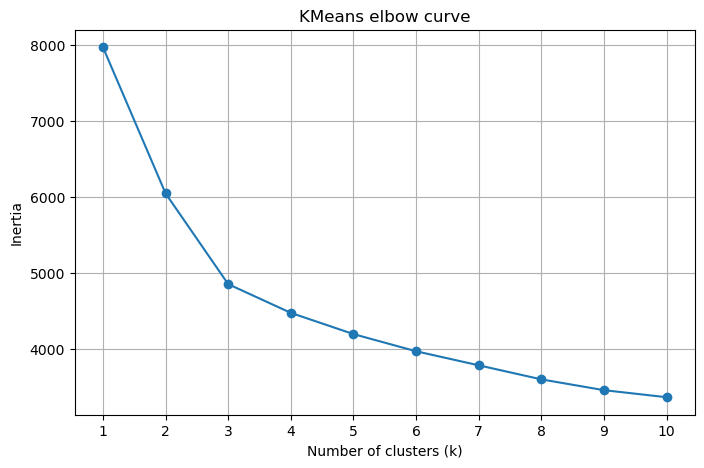

In [9]:
k_values_elbow = list(range(1, 11))
elbow_results = compute_kmeans_elbow(X_scaled, k_values_elbow)

display(elbow_results)

plt.figure(figsize=(8, 5))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans elbow curve")
plt.xticks(k_values_elbow)
plt.grid(True)
plt.show()

#### Quality metrics by k

We compare candidate values of `k` using:

- **silhouette score**: higher is better
- **Davies–Bouldin score**: lower is better
- **Calinski–Harabasz score**: higher is better

These metrics do not automatically determine the “correct” number of clusters, but they help identify plausible candidates for interpretation.

In [10]:
k_values_eval = list(range(2, 11))
kmeans_results = evaluate_kmeans(X_scaled, k_values_eval)

display(
    kmeans_results.sort_values("silhouette_score", ascending=False)
)

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,kmeans,3,0.220784,1.500712,29.792336
0,kmeans,2,0.209188,1.522558,29.841422
2,kmeans,4,0.199655,1.453232,23.883426
4,kmeans,6,0.194692,1.243758,18.080000
7,kmeans,9,0.127895,1.623224,14.138364
3,kmeans,5,0.114706,1.876816,20.404774
6,kmeans,8,0.114141,1.553455,15.206987
8,kmeans,10,0.104627,1.707326,13.026757
5,kmeans,7,0.092252,1.353037,16.346184


#### Silhouette score by k

Silhouette score is used here as the main clustering KPI.

Higher values indicate better separation between clusters.

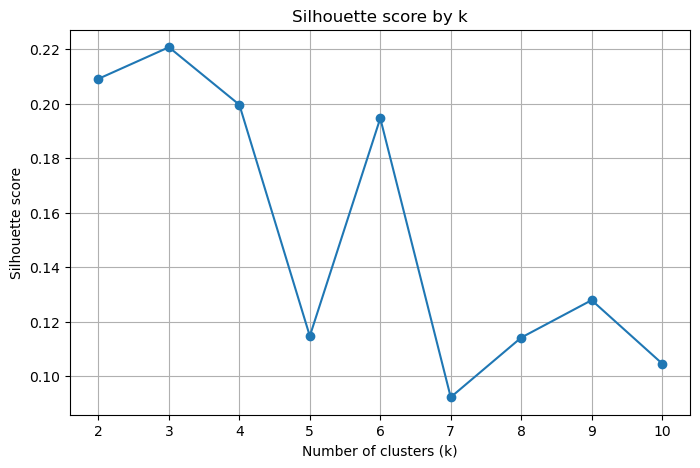

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results["k"],
    kmeans_results["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by k")
plt.xticks(k_values_eval)
plt.grid(True)
plt.show()

#### Diagnostic takeaway

Both the elbow curve and silhouette analysis converge on a clear result: **k = 3 is the most meaningful clustering solution**.

- The elbow curve stabilizes after k = 3  
- The silhouette score peaks at k = 3  
- Additional clusters reduce interpretability without improving separation  

This indicates that the feature space naturally organizes Berlin neighborhoods into **three distinct groups**, rather than a simple binary split.

The remainder of the analysis therefore focuses on **k = 3** as the primary segmentation.

## Section C. Baseline KMeans interpretation (k = 3)

This section focuses on interpreting the KMeans clustering for **k = 3**, which was identified as the most meaningful segmentation based on the diagnostic analysis.

For this configuration, we inspect:

- silhouette structure
- cluster sizes
- mean feature profiles
- standardized cluster profiles
- most distinguishing features
- neighborhood membership
- spatial cluster distribution

The objective is to understand how the feature space organizes Berlin neighborhoods into distinct groups, and to translate these clusters into interpretable urban patterns.

---

### Note on extensibility

The helper functions defined in this notebook allow the same analysis to be repeated for other values of `k`.

While the current results clearly support **k = 3** as the baseline, alternative configurations can be explored in the future as:

- additional features are introduced  
- feature engineering is refined  
- or different clustering objectives are considered

In [12]:
# Load database credentials from environment variables

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5433")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Quick connection test
query_test = "SELECT CURRENT_DATABASE();"

try:
    with engine.connect() as conn:
        result = conn.execute(text(query_test))
        for row in result:
            print("Connected to database:", row[0])
except SQLAlchemyError as e:
    print("Database connection failed.")
    print(e)

Connected to database: layereddb


In [13]:
query_neighborhood_geom = """
SELECT
    LPAD(neighborhood_id::text, 4, '0') AS neighborhood_id,
    neighborhood,
    district,
    geometry
FROM berlin_source_data.neighborhoods
WHERE geometry IS NOT NULL
"""

df_neigh_geom = pd.read_sql(text(query_neighborhood_geom), engine)

df_neigh_geom["geometry"] = df_neigh_geom["geometry"].apply(
    lambda x: wkb.loads(bytes.fromhex(x))
)

gdf_neigh = gpd.GeoDataFrame(
    df_neigh_geom,
    geometry="geometry",
    crs="EPSG:4326",
)

print("Neighborhood geometry rows:", len(gdf_neigh))
display(gdf_neigh.head())

Neighborhood geometry rows: 96


,neighborhood_id,neighborhood,district,geometry
0,0503,Siemensstadt,Spandau,"MULTIPOLYGON (((13.23776 52.53555, 13.23637 52.53528, 13.23316 52.53466, 13.23209 52.53445, 13.23159 52.53436, 13.23..."
1,0504,Staaken,Spandau,"MULTIPOLYGON (((13.16628 52.51527, 13.16644 52.51542, 13.1666 52.51557, 13.16674 52.51569, 13.16677 52.51572, 13.166..."
2,0903,Baumschulenweg,Treptow-Köpenick,"MULTIPOLYGON (((13.4842 52.44006, 13.48421 52.44006, 13.48453 52.44026, 13.48476 52.44041, 13.485 52.44056, 13.48502..."
3,0904,Johannisthal,Treptow-Köpenick,"MULTIPOLYGON (((13.4842 52.44006, 13.48426 52.44003, 13.48427 52.44002, 13.48433 52.44001, 13.4844 52.43999, 13.4845..."
4,0905,Niederschöneweide,Treptow-Köpenick,"MULTIPOLYGON (((13.5352 52.44787, 13.53525 52.44787, 13.53565 52.44789, 13.53606 52.44792, 13.53611 52.44792, 13.536..."


### Fit and inspect the baseline k = 3 solution

KMeans solution for k=3
Average silhouette score: 0.221


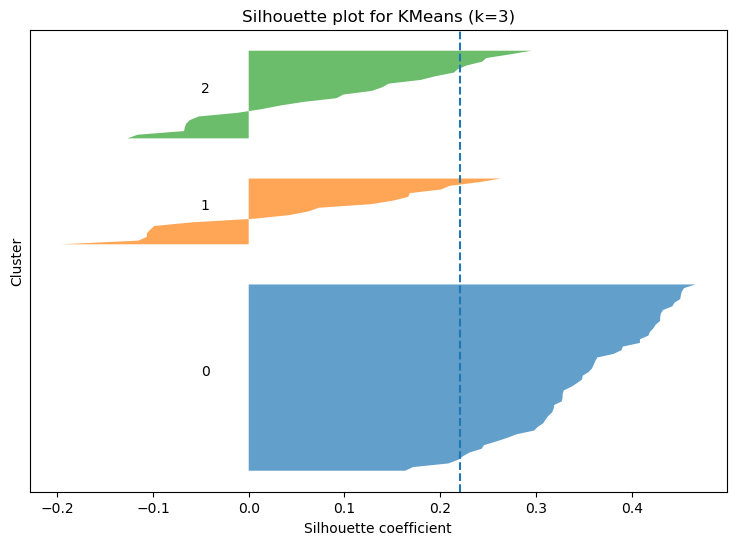

Cluster sizes


,cluster,n_neighborhoods
0,0,52
1,1,19
2,2,25


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1044.391,0.005,0.046,7.813,0.055,0.667,0.131,1.282,0.196,0.005,0.115,0.146,0.061,2.153,1.696,0.270,0.505,2.672,0.175,2.708,0.164,0.150,0.052,1799.064,435.636,0.769,0.066,0.158,1.962,0.809,0.063,1.410,3.032,1.661,0.897,0.0,1.564,0.144,1.123,0.291,0.552,0.148,4.120,0.122,8850.114,0.046,0.004,0.377,0.552,0.293,0.023,6.749,0.608,1344.373,811.998,287.959,914.865,696.921,1038.816,417.343,320.730,945.731,293.831,545.240,1311.587,644.840,1284.792,1749.551,1244.034,931.792,1157.816,1953.431,552.684,667.299,1495.561,1937.494,2249.335,2399.484,1831.935,1955.821,400.228,1750.900,1572.386,2337.169
1,1093.739,0.011,0.122,11.077,0.423,4.404,1.195,9.671,0.444,0.000,0.161,0.785,1.754,6.307,5.707,0.835,3.691,8.777,0.561,11.844,0.339,0.999,0.749,2937.851,564.847,2.449,0.222,0.347,7.593,2.656,0.143,2.987,6.467,6.171,7.857,0.0,4.689,1.496,2.839,1.275,3.880,0.464,38.823,0.474,12616.567,0.076,0.009,0.460,0.697,0.246,0.038,5.683,0.976,402.365,381.673,294.054,439.080,324.031,525.661,275.924,258.927,501.375,232.183,420.377,319.418,420.151,630.906,888.433,692.387,646.001,935.984,882.536,344.641,361.120,592.034,1076.575,1328.214,1502.605,1056.298,1097.803,322.975,528.162,854.476,942.229
2,1571.657,0.002,0.002,2.957,0.011,0.102,0.058,0.270,0.157,0.000,0.129,0.035,0.013,0.305,0.202,0.040,0.220,0.642,0.025,0.967,0.009,0.024,0.000,713.495,212.578,0.140,0.012,0.125,0.226,0.269,0.013,0.302,0.569,0.432,0.076,0.0,0.370,0.023,0.325,0.041,0.021,0.004,1.007,0.030,4140.038,0.037,0.001,0.031,0.710,0.420,0.028,4.638,1.047,3125.535,2221.425,669.365,2638.852,1759.267,2133.342,915.388,900.180,2443.629,1028.629,1421.273,3684.468,1671.840,2746.323,3969.745,2900.887,1267.711,1365.687,4425.670,16

Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.21,-0.12,-0.03,0.16,-0.27,-0.22,-0.20,-0.25,-0.17,0.09,-0.08,-0.27,-0.33,-0.13,-0.16,-0.11,-0.28,-0.19,-0.10,-0.25,0.02,-0.19,-0.24,0.06,0.16,-0.18,-0.11,-0.12,-0.14,-0.22,-0.01,-0.02,-0.00,-0.22,-0.33,0,-0.17,-0.34,-0.08,-0.18,-0.25,-0.05,-0.35,-0.18,0.12,-0.06,-0.07,0.06,-0.23,-0.07,-0.11,0.10,-0.15,-0.23,-0.33,-0.37,-0.32,-0.25,-0.18,-0.28,-0.39,-0.31,-0.41,-0.34,-0.24,-0.33,-0.18,-0.28,-0.25,-0.05,-0.01,-0.25,-0.36,-0.36,-0.28,-0.27,-0.26,-0.25,-0.27,-0.01,-0.35,-0.21,-0.28,-0.11
1,-0.14,1.27,0.55,1.02,1.33,1.18,0.89,1.27,0.90,-0.12,0.21,1.51,1.41,1.45,1.46,1.12,1.34,1.51,0.96,1.41,0.68,0.99,1.10,1.24,0.78,1.59,0.91,0.66,1.06,1.56,0.36,1.27,0.39,1.54,1.66,0,1.56,1.62,0.93,1.18,1.35,0.53,1.63,1.19,1.09,0.39,1.19,0.12,0.25,-0.20,0.28,-0.04,0.15,-1.00,-0.82,-0.34,-0.75,-0.71,-0.70,-0.67,-0.56,-0.78,-0.55,-0.55,-0.81,-0.67,-0.67,-0.87,-0.68,-0.51,-0.33,-0.86,-0.68,-0.71,-0.85,-0.83,-0.77,-0.75,-0.68,-0.79,-0.53,-0.94,-0.80,-0.91
2,0.54,-0.82,-0.36,-1.11,-0.46,-0.43,-0.27,-0.44,-0.33,-0.12,0.01,-0.58,-0.38,-0.83,-0.77,-0.61,-0.43,-0.76,-0.52,-0.56,-0.56,-0.36,-0.34,-1.07,-0.92,-0.84,-0.46,-0.26,-0.51,-0.74,-0.25,-0.93,-0.29,-0.71,-0.57,0,-0.83,-0.52,-0.54,-0.52,-0.50,-0.31,-0.52,-0.54,-1.09,-0.19,-0.83,-0.22,0.29,0.30,0.02,-0.17,0.21,1.23,1.30,1.02,1.23,1.06,0.92,1.09,1.23,1.25,1.28,1.14,1.11,1.20,0.89,1.25,1.04,0.49,0.28,1.17,1.27,1.30,1.23,1.19,1.12,1.08,1.08,0.62,1.13,1.15,1.19,0.92


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,parking_space_count_per_sq_km,0.16,0,higher
1,bus_stop_count_per_sq_km,0.16,0,higher
2,bike_lane_length_m_per_sq_km,0.12,0,higher
3,kindergarten_capacity_per_1000,0.10,0,higher
4,exhibition_center_count_per_sq_km,0.09,0,higher
5,milieuschutz_share,0.06,0,higher
6,parking_capacity_per_sq_km,0.06,0,higher
7,mall_count_per_sq_km,0.02,0,higher
8,short_term_listing_count_per_sq_km,-0.00,0,higher
9,stage_theater_count_per_sq_km,0.00,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k3
0,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0
1,Schmargendorf,Charlottenburg-Wilmersdorf,0
2,Westend,Charlottenburg-Wilmersdorf,0
3,Alt-Hohenschönhausen,Lichtenberg,0
4,Friedrichsfelde,Lichtenberg,0
5,Karlshorst,Lichtenberg,0
6,Lichtenberg,Lichtenberg,0
7,Neu-Hohenschönhausen,Lichtenberg,0
8,Rummelsburg,Lichtenberg,0
9,Biesdorf,Marzahn-Hellersdorf,0


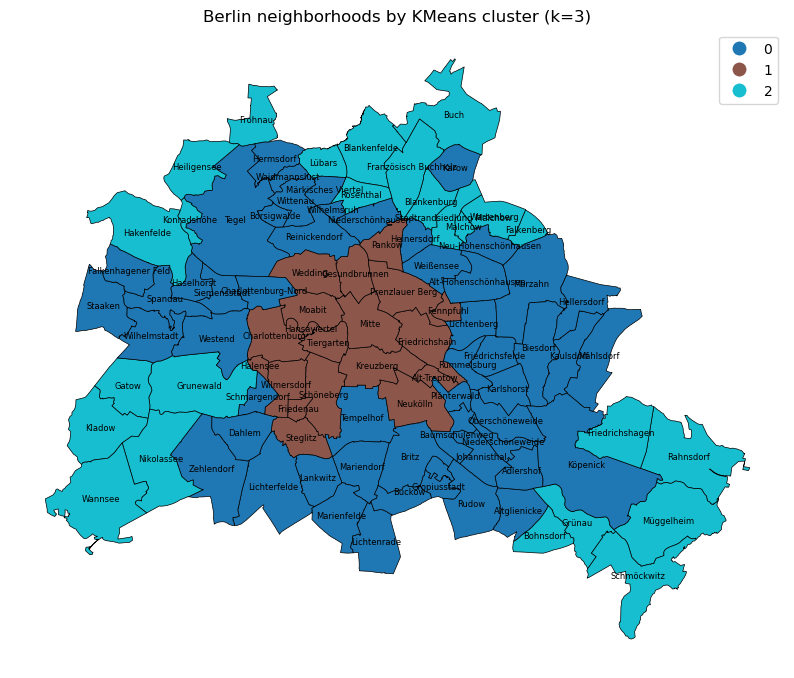

In [14]:
results_k3 = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_scaled,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=3,
    show_labels=True,
)

### Ambiguous neighborhoods

In [15]:
# -----------------------------------
# Start from the fitted result
# -----------------------------------

df_result = results_k3["df_result"].copy()
cluster_col = "cluster_kmeans_k3"

# Add per-neighborhood silhouette values
df_result["silhouette"] = results_k3["sample_silhouette_values"]

# -----------------------------------
# Reconstruct cluster centroids in scaled space
# -----------------------------------

labels = df_result[cluster_col].values
cluster_ids = np.sort(df_result[cluster_col].unique())

centroids = np.vstack([
    X_scaled[labels == cluster_id].mean(axis=0)
    for cluster_id in cluster_ids
])

# -----------------------------------
# Distance from each neighborhood to each centroid
# -----------------------------------

distance_matrix = np.linalg.norm(
    X_scaled[:, None, :] - centroids[None, :, :],
    axis=2
)

# Best cluster from distances
closest_cluster = cluster_ids[np.argmin(distance_matrix, axis=1)]

# Second-best cluster
second_best_idx = np.argsort(distance_matrix, axis=1)[:, 1]
second_best_cluster = cluster_ids[second_best_idx]

# Distances
assigned_cluster_idx = np.searchsorted(cluster_ids, labels)
distance_to_assigned = distance_matrix[np.arange(len(df_result)), assigned_cluster_idx]
distance_to_second_best = distance_matrix[np.arange(len(df_result)), second_best_idx]

# -----------------------------------
# Add diagnostics to dataframe
# -----------------------------------

df_result["closest_cluster_by_distance"] = closest_cluster
df_result["second_best_cluster"] = second_best_cluster
df_result["distance_to_assigned_cluster"] = distance_to_assigned
df_result["distance_to_second_best_cluster"] = distance_to_second_best
df_result["distance_gap"] = (
    df_result["distance_to_second_best_cluster"] -
    df_result["distance_to_assigned_cluster"]
)

# -----------------------------------
# Show only ambiguous neighborhoods
# -----------------------------------

ambiguous_neighborhoods = (
    df_result[df_result["silhouette"] < 0][
        [
            "neighborhood",
            "district",
            cluster_col,
            "silhouette",
            "second_best_cluster",
            "distance_to_assigned_cluster",
            "distance_to_second_best_cluster",
            "distance_gap",
        ]
    ]
    .sort_values("silhouette")
    .reset_index(drop=True)
)

display(ambiguous_neighborhoods)

,neighborhood,district,cluster_kmeans_k3,silhouette,second_best_cluster,distance_to_assigned_cluster,distance_to_second_best_cluster,distance_gap
0,Pankow,Pankow,1,-0.195693,0,6.672221,7.231088,0.558866
1,Rosenthal,Pankow,2,-0.126507,0,6.001679,6.380991,0.379312
2,Bohnsdorf,Treptow-Köpenick,2,-0.115972,0,5.355470,6.104158,0.748688
3,Tiergarten,Mitte,1,-0.115235,0,11.736938,12.292261,0.555323
4,Steglitz,Steglitz-Zehlendorf,1,-0.106545,0,7.791582,9.298306,1.506724
5,Wedding,Mitte,1,-0.106282,0,7.621465,9.148524,1.527059
6,Alt-Treptow,Treptow-Köpenick,1,-0.102854,0,11.351636,12.160159,0.808524
7,Fennpfuhl,Lichtenberg,1,-0.098725,0,10.958426,11.847950,0.889524
8,Blankenburg,Pankow,2,-0.067463,0,5.807830,7.040566,1.232736
9,Friedrichshagen,Treptow-Köpenick,2,-0.066718,0,5.930122,7.083330,1.153208


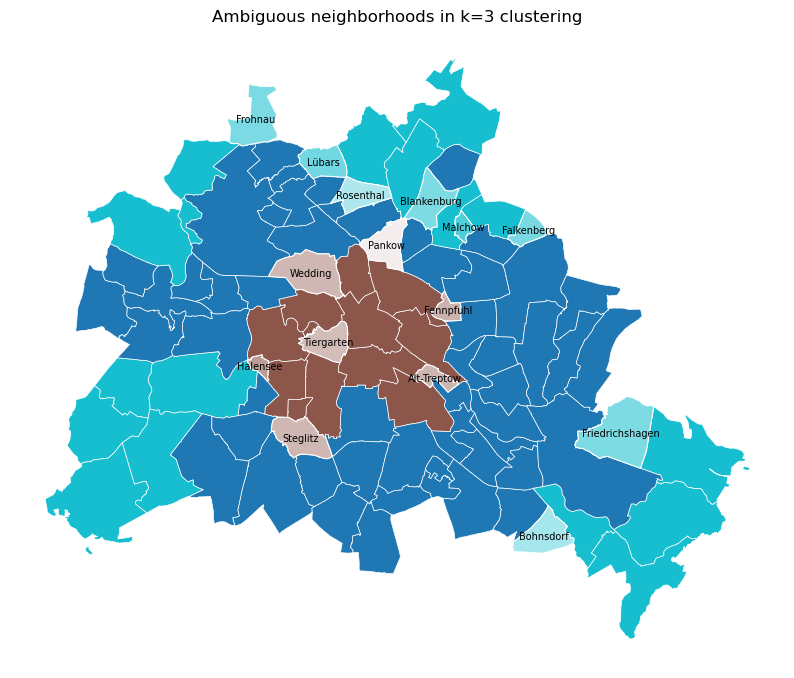

In [16]:
# -----------------------------------
# Helper to lighten a color
# -----------------------------------

def lighten_color(color, amount=0.55):
    """
    Lighten a matplotlib color by mixing it with white.
    Higher amount -> more faded
    """
    base = np.array(mcolors.to_rgb(color))
    white = np.array([1, 1, 1])
    return tuple(base + (white - base) * amount)

# -----------------------------------
# Fixed cluster colors
# -----------------------------------

cluster_colors = {
    0: "#1f77b4",  # blue
    1: "#8c564b",  # brown
    2: "#17becf",  # cyan
}

# -----------------------------------
# Build GeoDataFrames
# -----------------------------------

# Full city with assigned cluster colors
gdf_clusters = gdf_neigh.merge(
    df_result[["neighborhood_id", cluster_col]],
    on="neighborhood_id",
    how="left"
)

gdf_clusters["cluster_color"] = gdf_clusters[cluster_col].map(cluster_colors)

# Ambiguous neighborhoods only
gdf_ambiguous = gdf_neigh.merge(
    df_result[df_result["silhouette"] < 0][
        ["neighborhood_id", "silhouette", cluster_col, "second_best_cluster"]
    ],
    on="neighborhood_id",
    how="inner"
)

# -----------------------------------
# Fade ambiguous neighborhoods by silhouette
# More negative silhouette -> more faded
# -----------------------------------

sil_min = gdf_ambiguous["silhouette"].min()  # most negative
sil_max = 0

if sil_max > sil_min:
    gdf_ambiguous["fade_amount"] = 0.20 + 0.70 * (
        (sil_max - gdf_ambiguous["silhouette"]) / (sil_max - sil_min)
    )
else:
    gdf_ambiguous["fade_amount"] = 0.55

gdf_ambiguous["ambiguous_color"] = gdf_ambiguous.apply(
    lambda row: lighten_color(
        cluster_colors[row[cluster_col]],
        amount=row["fade_amount"]
    ),
    axis=1
)

# -----------------------------------
# Plot map
# -----------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Base map: all neighborhoods in cluster colors
gdf_clusters.plot(
    color=gdf_clusters["cluster_color"],
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

# Overlay ambiguous neighborhoods with faded cluster colors
gdf_ambiguous.plot(
    color=gdf_ambiguous["ambiguous_color"],
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Add neighborhood labels
for _, row in gdf_ambiguous.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["neighborhood"],
        fontsize=7,
        ha="center",
        va="center"
    )

ax.set_title("Ambiguous neighborhoods in k=3 clustering")
ax.set_axis_off()

plt.show()

### Interpreting the baseline k = 3 solution

The `k = 3` clustering produces a clear and interpretable three-part structure across Berlin.

The silhouette score is **0.221**, which is moderate but meaningful for a high-dimensional urban feature space. More importantly, the three clusters are:

- reasonably well separated in the silhouette plot
- geographically coherent on the map
- substantively interpretable from their feature profiles

Cluster sizes are also plausible:

- **Cluster 0:** 52 neighborhoods
- **Cluster 1:** 19 neighborhoods
- **Cluster 2:** 25 neighborhoods

This suggests that the model is not simply isolating a few outliers, but identifying three distinct neighborhood regimes.

---

#### Cluster 1: dense urban core

Cluster 1 forms the central core of the city.

It is characterized by:

- very high densities of:
  - doctors
  - pharmacies
  - supermarkets
  - venues
  - theaters
  - social clubs
  - spaetis
  - hotels
  - transport infrastructure
- very short distances to:
  - ATMs
  - bakeries
  - transport stations
  - libraries
  - government offices
  - food markets
  - other everyday services

This cluster represents the most **accessible, service-rich, and activity-dense urban areas** in Berlin.

---

#### Cluster 2: peripheral and low-access outer belt

Cluster 2 captures the most peripheral parts of Berlin.

It is characterized by:

- low densities of:
  - bus stops
  - schools
  - pharmacies
  - supermarkets
  - bike lanes
  - parking infrastructure
- long distances to:
  - bakeries
  - ATMs
  - parks
  - playgrounds
  - pharmacies
  - transport stations
  - government offices

This cluster represents the most **spatially dispersed and least accessible neighborhoods**, concentrated at the outer edges of the city.

---

#### Cluster 0: intermediate residential belt

Cluster 0 sits between the dense urban core and the peripheral outer belt.

It is characterized by:

- mostly near-average feature values
- moderate service density
- relatively good access to:
  - parks
  - playgrounds
  - bus stops
  - schools
  - supermarkets
- less nightlife, culture, and service intensity than the urban core

This cluster can be interpreted as a broad **intermediate residential belt**: neighborhoods that are not central urban hubs, but also not highly peripheral.

---

#### Ambiguous neighborhoods and boundary cases

A small number of neighborhoods show negative silhouette values in the k = 3 solution. These cases are not errors, but indicators of structural ambiguity in the feature space.

A consistent pattern emerges: all ambiguous neighborhoods are pulled toward **cluster 0**, the intermediate residential belt. This suggests that cluster 0 acts as a structural transition between the dense urban core and the peripheral outer belt.

Two main types of ambiguity can be observed:

- **Inner-edge ambiguity (cluster 1)**  
  Neighborhoods such as Pankow, Tiergarten, Wedding, Steglitz, and Alt-Treptow are assigned to the dense urban cluster, but show partial alignment with more residential patterns. These areas typically sit at the boundary of the urban core and combine high accessibility with lower or more uneven service density.  
  Tiergarten is a particularly clear example: its large park reduces amenity density despite its central location, creating a mixed signal across features.

- **Outer-transition ambiguity (cluster 2)**  
  Neighborhoods such as Rosenthal, Blankenburg, Frohnau, and Friedrichshagen are assigned to the peripheral cluster, but are relatively better connected or more locally developed than typical outer areas. These neighborhoods resemble suburban “self-contained” zones, sitting between fully peripheral and intermediate profiles.

- **Severity of ambiguity**  
  The most pronounced case is Pankow, which shows the strongest negative silhouette score and lies closest to the boundary between clusters. Other neighborhoods exhibit milder ambiguity, indicating gradual transitions rather than clear misclassification.

Overall, these cases highlight that Berlin’s spatial structure is continuous. The clustering captures dominant regimes well, but these neighborhoods reveal where boundaries between urban types are inherently fuzzy.

---

#### Baseline takeaway

The `k = 3` solution separates Berlin into three coherent and interpretable urban regimes:

1. dense urban core  
2. intermediate residential belt  
3. peripheral low-access outer belt  

Compared to a simple binary split, this structure captures a more realistic gradient of urban intensity across the city.

The presence of ambiguous neighborhoods reinforces this interpretation rather than weakening it. These cases consistently sit between clusters and are systematically drawn toward the intermediate belt, confirming that cluster 0 represents a transitional layer in the urban fabric.

Taken together, the results suggest that Berlin is best understood not as a set of sharply distinct zones, but as a continuous spectrum of neighborhood types anchored by three dominant regimes.

For this reason, **k = 3** provides a strong and interpretable baseline for further analysis.

## Section D. PCA interpretation of the feature space

After interpreting the selected KMeans solution, the next step is to examine the latent structure of the feature space itself.

PCA is used here as an **interpretation tool**, not as a replacement for clustering.

This section helps answer:

- what the dominant dimensions of variation are
- whether the dataset is driven by a single strong axis or multiple meaningful ones
- how these latent dimensions relate to urban structure in Berlin

We focus on:

- explained variance
- PCA projection of neighborhoods
- alignment between PCA structure and clustering
- component loadings for interpretation

### Explained variance by principal component

This shows how much of the total variance is captured by each principal component.

A dominant first component suggests that a large share of variation can be explained by a single underlying dimension, while a slower decay indicates a more complex, multi-dimensional structure.

In [17]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

display(explained_variance.head(15))

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.405898,0.405898
1,2,0.104539,0.510437
2,3,0.051273,0.561710
3,4,0.036365,0.598075
4,5,0.033387,0.631461
5,6,0.027444,0.658905
6,7,0.026524,0.685430
7,8,0.024166,0.709595
8,9,0.020657,0.730252
9,10,0.018529,0.748781


### Scree-style plot

The scree plot provides a visual view of how explained variance decreases across components.

It helps identify whether there is a clear "elbow" where additional components contribute only marginal information.

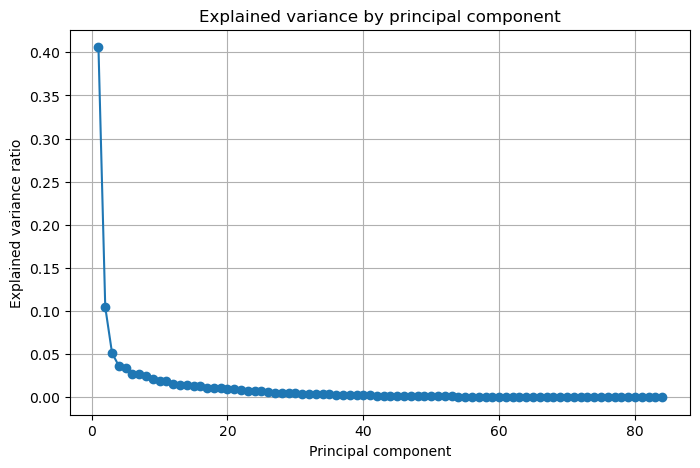

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance["component"],
    explained_variance["explained_variance_ratio"],
    marker="o"
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance by principal component")
plt.grid(True)
plt.show()

### Cumulative explained variance

The cumulative variance curve shows how many components are needed to capture a substantial share of the total variance.

This is useful for assessing how high-dimensional the dataset effectively is.

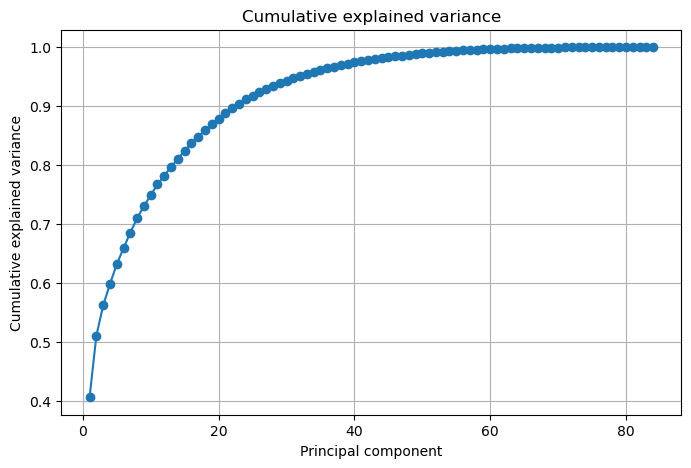

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance["component"],
    explained_variance["cumulative_explained_variance"],
    marker="o"
)
plt.xlabel("Principal component")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.grid(True)
plt.show()

### PCA projection of neighborhoods

To visualize the main structure of the feature space, neighborhoods are projected onto the first two principal components.

This does not replace clustering, but helps reveal whether neighborhoods are arranged along a single dominant axis or across multiple interpretable dimensions.

In [20]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = df.copy()
df_pca["pc1"] = X_pca_2[:, 0]
df_pca["pc2"] = X_pca_2[:, 1]

print("Explained variance by PC1 and PC2:")
print(np.round(pca_2.explained_variance_ratio_, 3))

display(df_pca[["neighborhood", "district", "pc1", "pc2"]].head())

Explained variance by PC1 and PC2:
[0.406 0.105]


,neighborhood,district,pc1,pc2
0,Charlottenburg,Charlottenburg-Wilmersdorf,11.547804,5.876629
1,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,-1.261206,-1.888345
2,Grunewald,Charlottenburg-Wilmersdorf,-9.175972,4.435717
3,Halensee,Charlottenburg-Wilmersdorf,6.424422,0.289408
4,Schmargendorf,Charlottenburg-Wilmersdorf,2.105467,-2.437605


### PCA projection colored by KMeans cluster

This plot shows how the k = 3 clustering sits within the first two principal components.

It is useful for checking whether cluster separation aligns with the dominant latent structure of the dataset.

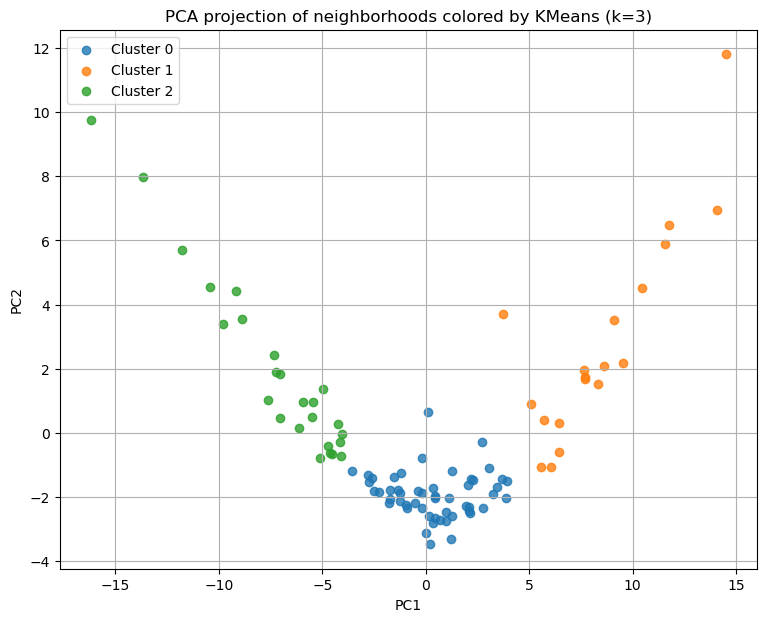

In [21]:
# Use the k=3 solution as the default for PCA interpretation
df_pca["cluster_kmeans_k3"] = results_k3["df_result"]["cluster_kmeans_k3"]

plt.figure(figsize=(9, 7))

for cluster_id in sorted(df_pca["cluster_kmeans_k3"].unique()):
    cluster_data = df_pca[df_pca["cluster_kmeans_k3"] == cluster_id]
    plt.scatter(
        cluster_data["pc1"],
        cluster_data["pc2"],
        label=f"Cluster {cluster_id}",
        alpha=0.8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of neighborhoods colored by KMeans (k=3)")
plt.legend()
plt.grid(True)
plt.show()

### PCA loadings

PCA loadings show which features contribute most strongly to each component.

To interpret the components, we inspect:

- the strongest positive contributors
- the strongest negative contributors

This helps translate abstract components into interpretable urban dimensions.

In [22]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=X_imputed.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

display(pca_components.head())

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
PC1,-0.045118,0.117742,0.054890,0.134779,0.117184,0.100222,0.057505,0.101062,0.077745,0.001925,0.017856,0.120917,0.108439,0.142137,0.139694,0.092468,0.108170,0.137619,0.092635,0.121580,0.083759,0.089163,0.089819,0.145970,0.112320,0.145630,0.080567,0.050194,0.083940,0.136108,0.039782,0.136927,0.044719,0.137990,0.126531,0.000000e+00,0.147497,0.128758,0.094322,0.101583,0.119681,0.050603,0.130004,0.110824,0.140744,0.032677,0.122999,0.022028,-0.005092,-0.024244,0.019973,0.014059,-0.016985,-0.143850,-0.146693,-0.085491,-0.138784,-0.124891,-0.115241,-0.117151,-0.124813,-0.142990,-0.130377,-0.123085,-0.136804,-0.135095,-0.101507,-0.145317,-0.129408,-0.066206,-0.039195,-0.139628,-0.125655,-0.130722,-0.140109,-0.141768,-0.132657,-0.126087,-0.123184,-0.079588,-0.102597,-0.129161,-0.133892,-0.126581
PC2,0.113557,0.123698,0.014749,-0.023043,0.171249,0.110348,0.128390,0.104904,0.077766,-0.026735,0.016591,0.114196,0.208538,0.105212,0.122449,0.027635,0.188737,0.094213,0.118906,0.146331,0.014467,0.188103,0.170559,-0.008767,-0.046285,0.083977,0.061308,0.027252,0.086672,0.105209,0.044097,0.027253,0.015642,0.134718,0.146952,0.000000e+00,0.086803,0.200499,0.064140,0.106875,0.180178,0.072477,0.197717,0.108782,-0.025124,-0.021851,0.009771,-0.017109,0.080773,-0.007559,0.066671,-0.055444,0.120781,0.085049,0.136285,0.123057,0.146485,0.123441,0.105397,0.104585,0.133773,0.150088,0.161611,0.158083,0.120564,0.156588,0.043828,0.108311,0.144715,0.020250,0.018001,0.102115,0.104451,0.114209,0.115325,0.112621,0.119057,0.122193,0.115588,-0.061533,0.112606,0.046191,0.133545,0.070275
PC3,-0.101820,-0.200196,-0.007310,0.083235,0.043124,0.267283,-0.206487,0.247635,0.070292,-0.026861,0.107715,-0.016821,-0.139489,-0.029068,-0.032276,-0.022292,-0.122373,0.213932,-0.233863,0.119131,-0.004278,-

#### PC1 loadings

The first principal component captures the dominant structural axis of the dataset.

In [23]:
pc1_pos = pca_components.loc["PC1"].sort_values(ascending=False).head(10)
pc1_neg = pca_components.loc["PC1"].sort_values(ascending=True).head(10)

print("Top positive contributors to PC1")
display(pc1_pos)

print("Top negative contributors to PC1")
display(pc1_neg)

Top positive contributors to PC1


supermarket_count_per_sq_km              0.147497
parking_capacity_per_sq_km               0.145970
pharmacy_count_per_sq_km                 0.145630
gas_station_count_per_sq_km              0.142137
bike_lane_length_m_per_sq_km             0.140744
gas_station_electric_count_per_sq_km     0.139694
social_club_count_per_sq_km              0.137990
kindergarten_count_per_sq_km             0.137619
school_count_per_sq_km                   0.136927
religious_institution_count_per_sq_km    0.136108
Name: PC1, dtype: float64

Top negative contributors to PC1


avg_dist_5_bakery_m              -0.146693
avg_dist_5_transport_station_m   -0.145317
avg_dist_5_atm_m                 -0.143850
avg_dist_5_pharmacy_m            -0.142990
avg_dist_3_library_m             -0.141768
avg_dist_3_government_office_m   -0.140109
avg_dist_3_food_market_m         -0.139628
avg_dist_3_dental_office_m       -0.138784
avg_dist_5_spaeti_m              -0.136804
avg_dist_5_supermarket_m         -0.135095
Name: PC1, dtype: float64

#### PC2 loadings

The second principal component captures a secondary dimension that is not explained by the dominant PC1 axis.

In [24]:
pc2_pos = pca_components.loc["PC2"].sort_values(ascending=False).head(10)
pc2_neg = pca_components.loc["PC2"].sort_values(ascending=True).head(10)

print("Top positive contributors to PC2")
display(pc2_pos)

print("Top negative contributors to PC2")
display(pc2_neg)

Top positive contributors to PC2


gallery_count_per_sq_km                       0.208538
theater_count_per_sq_km                       0.200499
venue_count_per_sq_km                         0.197717
hotel_count_per_sq_km                         0.188737
museum_count_per_sq_km                        0.188103
transport_station_entrance_count_per_sq_km    0.180178
cinema_count_per_sq_km                        0.171249
night_club_count_per_sq_km                    0.170559
avg_dist_3_playground_m                       0.161611
avg_dist_3_school_m                           0.158083
Name: PC2, dtype: float64

Top negative contributors to PC2


avg_dist_3_pool_m                   -0.061533
kindergarten_capacity_per_1000      -0.055444
parking_space_count_per_sq_km       -0.046285
exhibition_center_count_per_sq_km   -0.026735
bike_lane_length_m_per_sq_km        -0.025124
bus_stop_count_per_sq_km            -0.023043
park_share                          -0.021851
milieuschutz_share                  -0.017109
parking_capacity_per_sq_km          -0.008767
school_count_per_1000               -0.007559
Name: PC2, dtype: float64

#### PC3 loadings

The third principal component captures additional nuance beyond the first two dimensions.

It is typically weaker and should be interpreted cautiously.

In [25]:
pc3_pos = pca_components.loc["PC3"].sort_values(ascending=False).head(10)
pc3_neg = pca_components.loc["PC3"].sort_values(ascending=True).head(10)

print("Top positive contributors to PC3")
display(pc3_pos)

print("Top negative contributors to PC3")
display(pc3_neg)

Top positive contributors to PC3


dental_office_count_per_sq_km         0.267283
doctor_count_per_sq_km                0.247635
short_term_listing_count_per_sq_km    0.220691
kindergarten_count_per_sq_km          0.213932
parking_space_count_per_sq_km         0.209490
parking_capacity_per_sq_km            0.156983
supermarket_count_per_sq_km           0.154075
pharmacy_count_per_sq_km              0.134399
vocational_school_count_per_sq_km     0.130743
long_term_listing_count_per_sq_km     0.119131
Name: PC3, dtype: float64

Top negative contributors to PC3


library_count_per_sq_km              -0.233863
public_artwork_count_per_sq_km       -0.215786
diplomatic_mission_count_per_sq_km   -0.206487
accessibility_ratio                  -0.200196
museum_count_per_sq_km               -0.195307
university_count_per_sq_km           -0.187884
kindergarten_capacity_per_1000       -0.157885
dist_1_emergency_station_m           -0.153497
research_institute_count_per_sq_km   -0.149253
night_club_count_per_sq_km           -0.140691
Name: PC3, dtype: float64

### PCA interpretation summary

The PCA results reveal a clear and structured geometry of the feature space.

**PC1 (≈ 41% of variance)** is the dominant axis and represents a combined dimension of:

- urban intensity
- everyday service density
- accessibility

Neighborhoods with high PC1 values are characterized by:

- high densities of everyday infrastructure (supermarkets, pharmacies, schools, services)
- strong transport connectivity
- short distances to amenities

Neighborhoods with low PC1 values show the opposite pattern:

- lower service density
- longer distances to everyday functions
- more spatial dispersion

PC1 can therefore be interpreted as a continuous measure of **urban centrality and accessibility**, forming the backbone of the dataset.

---

**PC2 (≈ 10% of variance)** introduces a second, orthogonal dimension related to:

- culture
- nightlife
- tourism and destination-oriented activity

High PC2 values correspond to neighborhoods with:

- galleries, theaters, venues, museums, hotels
- nightlife and cultural infrastructure
- strong presence of transport entrances

This dimension differentiates **types of urban areas**, rather than their overall intensity:

- not *how dense a neighborhood is*
- but *what kind of urban life it supports*

---

**PC3 (≈ 5% of variance)** captures additional nuance but is less cleanly interpretable.

It appears to separate:

- service-heavy, residential-commercial areas (positive side)
- from more institutional, cultural, or civic-oriented environments (negative side)

However, its contribution is significantly weaker and more mixed, so it should be treated as a **secondary refinement rather than a primary structural axis**.

---

#### Alignment with clustering

The PCA projection confirms that the **k = 3 clustering aligns closely with the latent structure of the data**:

- one cluster occupies the high PC1 region (dense urban core)
- one cluster lies in the intermediate range (residential belt)
- one cluster occupies the low PC1 region (peripheral areas)

PC2 further helps explain differences within dense areas, especially the distinction between culturally intensive neighborhoods and more residential ones.

---

#### PCA takeaway

The feature space is primarily organized along a strong centrality axis (PC1), with a secondary layer of functional differentiation (PC2), and additional weaker nuance (PC3).

This structure explains why:

- a simple split (k = 2) captures the main contrast in the city
- but **k = 3 provides a more meaningful and interpretable segmentation**

## Section E. KMeans on PCA-reduced space

In previous sections, clustering was performed on the full standardized feature space.

Here, we test whether clustering improves when the feature space is first compressed using PCA.

The goal is to evaluate:

- whether dimensionality reduction improves cluster separation
- whether the same neighborhood structure remains visible after compression
- how PCA-based clustering compares with the full-feature baseline

This is not assumed to be better by default. The purpose is to test whether PCA simplifies the geometry of the dataset while preserving its substantive structure.

### Select number of PCA components

The number of retained principal components is selected based on cumulative explained variance.

A common heuristic is to retain enough components to preserve around **80% of total variance**, balancing dimensionality reduction against information loss.

In [26]:
# Inspect cumulative explained variance again
display(explained_variance.head(20))

# Choose number of components (adjust if needed)
n_components = 14

pca_reduced = PCA(n_components=n_components)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print("Reduced PCA shape:", X_pca_reduced.shape)
print("Explained variance retained:", np.sum(pca_reduced.explained_variance_ratio_))

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.405898,0.405898
1,2,0.104539,0.510437
2,3,0.051273,0.561710
3,4,0.036365,0.598075
4,5,0.033387,0.631461
5,6,0.027444,0.658905
6,7,0.026524,0.685430
7,8,0.024166,0.709595
8,9,0.020657,0.730252
9,10,0.018529,0.748781


Reduced PCA shape: (96, 14)
Explained variance retained: 0.8107819591630384


### KMeans diagnostics on PCA-reduced space

We now rerun the same KMeans diagnostics on the PCA-reduced feature space.

This allows a direct comparison with the clustering results obtained from the full feature space.

In [27]:
k_values_eval = list(range(2, 15))

kmeans_results_pca = evaluate_kmeans(X_pca_reduced, k_values_eval)

display(
    kmeans_results_pca.sort_values("silhouette_score", ascending=False)
)

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,kmeans,3,0.293701,1.211317,42.634613
2,kmeans,4,0.278437,1.117346,34.968103
0,kmeans,2,0.267214,1.262312,39.446744
4,kmeans,6,0.205530,1.376795,27.295349
7,kmeans,9,0.202027,1.307632,23.129445
5,kmeans,7,0.198965,1.289856,25.369187
3,kmeans,5,0.194296,1.418495,30.541114
8,kmeans,10,0.173506,1.273836,21.993229
12,kmeans,14,0.163545,1.198465,19.449174
11,kmeans,13,0.155010,1.178570,19.417162


### Silhouette comparison: full feature space vs PCA-reduced space

To compare the two approaches directly, we examine silhouette scores across values of `k` for:

- the full feature space
- the PCA-reduced space

This shows whether dimensionality reduction improves cluster separation and whether it changes the ranking of candidate clustering solutions.

,model_full,k,silhouette_score_full,davies_bouldin_score_full,calinski_harabasz_score_full,model_pca,silhouette_score_pca,davies_bouldin_score_pca,calinski_harabasz_score_pca
0,kmeans,2,0.209188,1.522558,29.841422,kmeans,0.267214,1.262312,39.446744
1,kmeans,3,0.220784,1.500712,29.792336,kmeans,0.293701,1.211317,42.634613
2,kmeans,4,0.199655,1.453232,23.883426,kmeans,0.278437,1.117346,34.968103
3,kmeans,5,0.114706,1.876816,20.404774,kmeans,0.194296,1.418495,30.541114
4,kmeans,6,0.194692,1.243758,18.080000,kmeans,0.205530,1.376795,27.295349
5,kmeans,7,0.092252,1.353037,16.346184,kmeans,0.198965,1.289856,25.369187
6,kmeans,8,0.114141,1.553455,15.206987,kmeans,0.145120,1.338939,24.342023
7,kmeans,9,0.127895,1.623224,14.138364,kmeans,0.202027,1.307632,23.129445
8,kmeans,10,0.104627,1.707326,13.026757,kmeans,0.173506,1.273836,21.993229


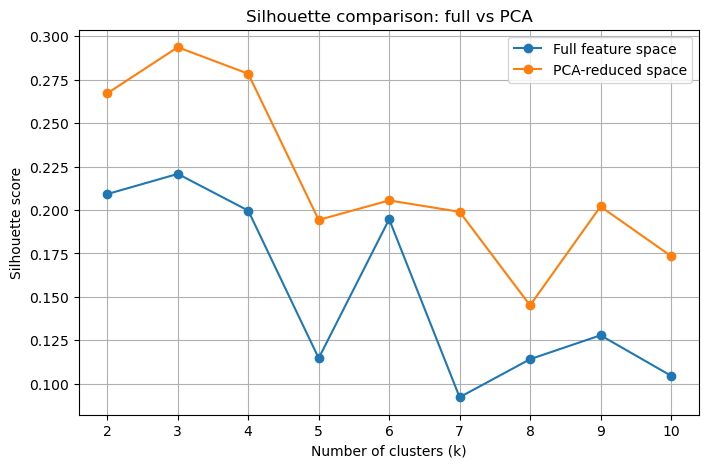

In [28]:
comparison = kmeans_results.merge(
    kmeans_results_pca,
    on="k",
    suffixes=("_full", "_pca")
)

display(comparison)

plt.figure(figsize=(8, 5))

plt.plot(
    comparison["k"],
    comparison["silhouette_score_full"],
    marker="o",
    label="Full feature space"
)

plt.plot(
    comparison["k"],
    comparison["silhouette_score_pca"],
    marker="o",
    label="PCA-reduced space"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette comparison: full vs PCA")
plt.legend()
plt.grid(True)
plt.show()

### Fit KMeans on PCA-reduced space

After comparing diagnostics, we inspect the PCA-based clustering solution in more detail.

We use the same helper function as before, but with the reduced feature matrix, in order to check whether the resulting clusters remain spatially coherent and substantively interpretable.

KMeans solution for k=3
Average silhouette score: 0.294


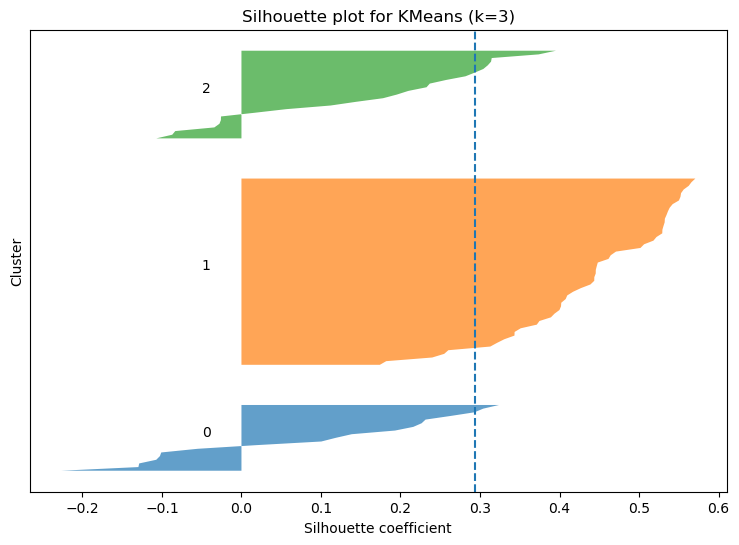

Cluster sizes


,cluster,n_neighborhoods
0,0,19
1,1,52
2,2,25


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1093.739,0.011,0.122,11.077,0.423,4.404,1.195,9.671,0.444,0.000,0.161,0.785,1.754,6.307,5.707,0.835,3.691,8.777,0.561,11.844,0.339,0.999,0.749,2937.851,564.847,2.449,0.222,0.347,7.593,2.656,0.143,2.987,6.467,6.171,7.857,0.0,4.689,1.496,2.839,1.275,3.880,0.464,38.823,0.474,12616.567,0.076,0.009,0.460,0.697,0.246,0.038,5.683,0.976,402.365,381.673,294.054,439.080,324.031,525.661,275.924,258.927,501.375,232.183,420.377,319.418,420.151,630.906,888.433,692.387,646.001,935.984,882.536,344.641,361.120,592.034,1076.575,1328.214,1502.605,1056.298,1097.803,322.975,528.162,854.476,942.229
1,1044.391,0.005,0.046,7.813,0.055,0.667,0.131,1.282,0.196,0.005,0.115,0.146,0.061,2.153,1.696,0.270,0.505,2.672,0.175,2.708,0.164,0.150,0.052,1799.064,435.636,0.769,0.066,0.158,1.962,0.809,0.063,1.410,3.032,1.661,0.897,0.0,1.564,0.144,1.123,0.291,0.552,0.148,4.120,0.122,8850.114,0.046,0.004,0.377,0.552,0.293,0.023,6.749,0.608,1344.373,811.998,287.959,914.865,696.921,1038.816,417.343,320.730,945.731,293.831,545.240,1311.587,644.840,1284.792,1749.551,1244.034,931.792,1157.816,1953.431,552.684,667.299,1495.561,1937.494,2249.335,2399.484,1831.935,1955.821,400.228,1750.900,1572.386,2337.169
2,1571.657,0.002,0.002,2.957,0.011,0.102,0.058,0.270,0.157,0.000,0.129,0.035,0.013,0.305,0.202,0.040,0.220,0.642,0.025,0.967,0.009,0.024,0.000,713.495,212.578,0.140,0.012,0.125,0.226,0.269,0.013,0.302,0.569,0.432,0.076,0.0,0.370,0.023,0.325,0.041,0.021,0.004,1.007,0.030,4140.038,0.037,0.001,0.031,0.710,0.420,0.028,4.638,1.047,3125.535,2221.425,669.365,2638.852,1759.267,2133.342,915.388,900.180,2443.629,1028.629,1421.273,3684.468,1671.840,2746.323,3969.745,2900.887,1267.711,1365.687,4425.670,16

Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.14,1.27,0.55,1.02,1.33,1.18,0.89,1.27,0.90,-0.12,0.21,1.51,1.41,1.45,1.46,1.12,1.34,1.51,0.96,1.41,0.68,0.99,1.10,1.24,0.78,1.59,0.91,0.66,1.06,1.56,0.36,1.27,0.39,1.54,1.66,0,1.56,1.62,0.93,1.18,1.35,0.53,1.63,1.19,1.09,0.39,1.19,0.12,0.25,-0.20,0.28,-0.04,0.15,-1.00,-0.82,-0.34,-0.75,-0.71,-0.70,-0.67,-0.56,-0.78,-0.55,-0.55,-0.81,-0.67,-0.67,-0.87,-0.68,-0.51,-0.33,-0.86,-0.68,-0.71,-0.85,-0.83,-0.77,-0.75,-0.68,-0.79,-0.53,-0.94,-0.80,-0.91
1,-0.21,-0.12,-0.03,0.16,-0.27,-0.22,-0.20,-0.25,-0.17,0.09,-0.08,-0.27,-0.33,-0.13,-0.16,-0.11,-0.28,-0.19,-0.10,-0.25,0.02,-0.19,-0.24,0.06,0.16,-0.18,-0.11,-0.12,-0.14,-0.22,-0.01,-0.02,-0.00,-0.22,-0.33,0,-0.17,-0.34,-0.08,-0.18,-0.25,-0.05,-0.35,-0.18,0.12,-0.06,-0.07,0.06,-0.23,-0.07,-0.11,0.10,-0.15,-0.23,-0.33,-0.37,-0.32,-0.25,-0.18,-0.28,-0.39,-0.31,-0.41,-0.34,-0.24,-0.33,-0.18,-0.28,-0.25,-0.05,-0.01,-0.25,-0.36,-0.36,-0.28,-0.27,-0.26,-0.25,-0.27,-0.01,-0.35,-0.21,-0.28,-0.11
2,0.54,-0.82,-0.36,-1.11,-0.46,-0.43,-0.27,-0.44,-0.33,-0.12,0.01,-0.58,-0.38,-0.83,-0.77,-0.61,-0.43,-0.76,-0.52,-0.56,-0.56,-0.36,-0.34,-1.07,-0.92,-0.84,-0.46,-0.26,-0.51,-0.74,-0.25,-0.93,-0.29,-0.71,-0.57,0,-0.83,-0.52,-0.54,-0.52,-0.50,-0.31,-0.52,-0.54,-1.09,-0.19,-0.83,-0.22,0.29,0.30,0.02,-0.17,0.21,1.23,1.30,1.02,1.23,1.06,0.92,1.09,1.23,1.25,1.28,1.14,1.11,1.20,0.89,1.25,1.04,0.49,0.28,1.17,1.27,1.30,1.23,1.19,1.12,1.08,1.08,0.62,1.13,1.15,1.19,0.92


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,spaeti_count_per_sq_km,1.66,0,higher
1,venue_count_per_sq_km,1.63,0,higher
2,theater_count_per_sq_km,1.62,0,higher
3,pharmacy_count_per_sq_km,1.59,0,higher
4,supermarket_count_per_sq_km,1.56,0,higher
5,religious_institution_count_per_sq_km,1.56,0,higher
6,social_club_count_per_sq_km,1.54,0,higher
7,kindergarten_count_per_sq_km,1.51,0,higher
8,food_market_count_per_sq_km,1.51,0,higher
9,gas_station_electric_count_per_sq_km,1.46,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k3
0,Charlottenburg,Charlottenburg-Wilmersdorf,0
1,Halensee,Charlottenburg-Wilmersdorf,0
2,Wilmersdorf,Charlottenburg-Wilmersdorf,0
3,Friedrichshain,Friedrichshain-Kreuzberg,0
4,Kreuzberg,Friedrichshain-Kreuzberg,0
5,Fennpfuhl,Lichtenberg,0
6,Gesundbrunnen,Mitte,0
7,Hansaviertel,Mitte,0
8,Mitte,Mitte,0
9,Moabit,Mitte,0


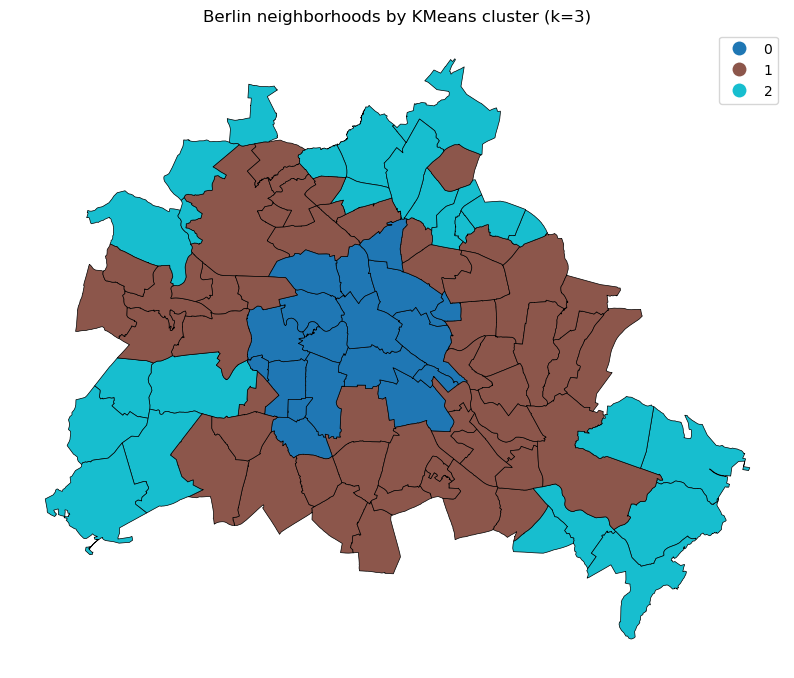

In [29]:
results_k3_pca = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_pca_reduced,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=3,
)

### PCA-reduced KMeans summary

To test whether clustering benefits from a more compact representation of the feature space, KMeans was also run on a PCA-reduced version of the dataset.

Based on the PCA analysis in Section D, **14 principal components** were retained. This preserves just over **80% of the total variance**, while reducing dimensionality substantially.

The goal of this step is not to replace the full-feature analysis, but to check whether PCA:

- improves cluster separation
- stabilizes the clustering structure
- or changes the substantive interpretation of neighborhood groups

---

#### Diagnostic comparison with the full feature space

Across all tested values of `k`, the PCA-reduced space produces **consistently higher silhouette scores** than the full feature space.

The strongest result is again observed at **k = 3**, where the silhouette score increases from approximately **0.221** in the full feature space to **0.294** in the PCA-reduced space.

This suggests that PCA helps by:

- compressing redundant information
- reducing noise from highly correlated features
- preserving the dominant latent dimensions of the dataset

At the same time, the diagnostic ranking of candidate values of `k` remains broadly similar:

- `k = 3` is still the best solution
- `k = 2` and `k = 4` remain plausible but weaker
- higher values of `k` continue to reduce interpretability

---

#### Interpretation of the PCA-based k = 3 solution

The substantive structure of the PCA-based clustering is almost identical to the clustering obtained in the full feature space.

The three clusters still correspond to the same urban regimes:

1. **dense urban core**
2. **intermediate residential belt**
3. **peripheral low-access outer belt**

This is visible in several ways:

- the cluster profiles remain highly consistent
- the neighborhood membership changes very little
- the map preserves the same overall spatial pattern

In other words, PCA improves statistical separation **without changing the meaning of the clusters**.

This is an important result. It indicates that the baseline k = 3 structure is not an artifact of the original high-dimensional space, but a robust underlying pattern that remains visible after dimensionality reduction.

---

#### Practical takeaway

Running KMeans on the PCA-reduced space improves clustering quality while preserving interpretability.

This suggests that PCA can be used as a useful preprocessing step when the goal is to:

- reduce dimensionality
- improve cluster cohesion and separation
- retain the main urban structure of the city

At the same time, because the PCA-based solution does not materially change the interpretation of the clusters, the full-feature and PCA-based analyses can be seen as **complementary validations of the same three-part neighborhood structure**.

For the purposes of this notebook, the main conclusion remains unchanged:

- **k = 3** is the most meaningful baseline segmentation of Berlin neighborhoods
- PCA strengthens this conclusion by producing the same substantive structure with better cluster separation

## Section F. DBSCAN on PCA-reduced space

In addition to KMeans, we tested DBSCAN as an alternative clustering approach on the PCA-reduced feature space.

DBSCAN differs fundamentally from KMeans:

- it does not require specifying the number of clusters in advance
- it identifies clusters based on density
- it can label points as noise if they do not belong to any dense region

This makes it attractive in settings where clusters are irregular or where noise is meaningful.

---

### k-distance diagnostic

To assess whether DBSCAN is suitable, we inspected the k-distance plot.

The curve shows a **smooth increase followed by gradual acceleration**, with no clear elbow.

This indicates that the dataset does not exhibit **distinct density-separated regions**, but rather a continuous distribution of points in feature space.

---

### DBSCAN results

Across a range of `eps` values, DBSCAN consistently produced the same outcome:

- a single large cluster containing most neighborhoods
- a small number of points labeled as noise
- no meaningful multi-cluster structure

---

### Why DBSCAN is not suitable here

This behavior is consistent with the structure of the dataset.

DBSCAN performs best when:

- clusters form **dense, well-separated regions**
- there are **clear gaps** between groups

However, Berlin neighborhoods form a **continuous urban gradient**, not discrete density clusters:

- urban intensity changes gradually from center to periphery
- intermediate areas smoothly connect different parts of the city
- even after PCA compression, the feature space remains globally connected

As a result:

- most neighborhoods fall into a single connected region
- only a few edge cases are identified as noise
- no stable or interpretable cluster structure emerges

---

### DBSCAN takeaway

DBSCAN does not provide a meaningful segmentation for this dataset.

This reinforces a key structural insight:

- Berlin’s neighborhood space is **continuous and layered**, not composed of sharply separated density-based clusters

For this reason, the analysis focuses on KMeans-based clustering, which is better suited to capturing broad urban regimes in this type of feature space.

## Section G. User-intent weighting

So far, clustering has been performed using all features with equal importance.

In practice, neighborhood preferences are not uniform. Different users prioritize different aspects of urban life.

Examples:

- families may prioritize schools, childcare, and playground access  
- nightlife-oriented users may prioritize venues, clubs, and late-hour infrastructure  
- commuters may prioritize transport connectivity and accessibility  

This section introduces **user-intent weighting**, where selected feature groups are amplified before clustering.

The goal is to understand:

- how user preferences reshape neighborhood similarity  
- which preference dimensions meaningfully alter the clustering structure  
- which dimensions are weak relative to the dominant urban pattern  
- how a future recommendation system could incorporate continuous user control  

In [30]:
# -----------------------------------
# User-intent feature groups
# -----------------------------------

group_feature_map = {
    "family": [
        "kindergarten_count_per_1000",
        "school_count_per_1000",
        "kindergarten_capacity_per_1000",
        "playground_share",
        "avg_dist_3_school_m",
        "avg_dist_3_playground_m",
    ],
    "nightlife": [
        "venue_count_per_sq_km",
        "spaeti_count_per_sq_km",
        "social_club_count_per_sq_km",
        "theater_count_per_sq_km",
        "cinema_count_per_sq_km",
        "night_club_count_per_sq_km",
        "avg_dist_5_spaeti_m",
        "avg_dist_5_transport_station_m",
    ],
    "transport": [
        "bus_stop_count_per_sq_km",
        "tram_stop_count_per_sq_km",
        "transport_station_count_per_sq_km",
        "transport_station_entrance_count_per_sq_km",
        "bike_lane_length_m_per_sq_km",
        "avg_dist_5_transport_station_m",
        "avg_dist_5_bus_stop_m",
        "avg_dist_5_tram_stop_m",
    ],
}

# Keep only features that actually exist
group_feature_map = {
    group: [f for f in features if f in X_imputed.columns]
    for group, features in group_feature_map.items()
}

# Optional display
display(
    pd.DataFrame({
        group: pd.Series(features)
        for group, features in group_feature_map.items()
    })
)

,family,nightlife,transport
0,kindergarten_count_per_1000,venue_count_per_sq_km,bus_stop_count_per_sq_km
1,school_count_per_1000,spaeti_count_per_sq_km,tram_stop_count_per_sq_km
2,kindergarten_capacity_per_1000,social_club_count_per_sq_km,transport_station_count_per_sq_km
3,playground_share,theater_count_per_sq_km,transport_station_entrance_count_per_sq_km
4,avg_dist_3_school_m,cinema_count_per_sq_km,bike_lane_length_m_per_sq_km
5,avg_dist_3_playground_m,night_club_count_per_sq_km,avg_dist_5_transport_station_m
6,NaN,avg_dist_5_spaeti_m,avg_dist_5_bus_stop_m
7,NaN,avg_dist_5_transport_station_m,avg_dist_5_tram_stop_m


### G1. Family-oriented clustering

This profile emphasizes features related to:

- schools  
- childcare availability  
- playground access  

The goal is to assess whether family-related infrastructure forms a distinct clustering signal, or whether it remains secondary to the broader urban structure.

#### Weight sensitivity

In [31]:
weight_values = [0.5, 1, 2, 3, 5, 10, 20, 50, 100, 500, 1000]
family_weight_for_sensitivity_k = 3

family_weight_stability = weight_stability_analysis(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="family",
    weight_values=weight_values,
    k=family_weight_for_sensitivity_k,
)

display(family_weight_stability)

,weight,silhouette_score,ari_vs_baseline
0,0.5,0.222798,1.000000
1,1.0,0.220784,1.000000
2,2.0,0.216211,0.967962
3,3.0,0.235682,0.541164
4,5.0,0.249965,0.447182
5,10.0,0.331405,0.349697
6,20.0,0.351285,0.349697
7,50.0,0.358701,0.349697
8,100.0,0.359875,0.349697
9,500.0,0.360259,0.349697


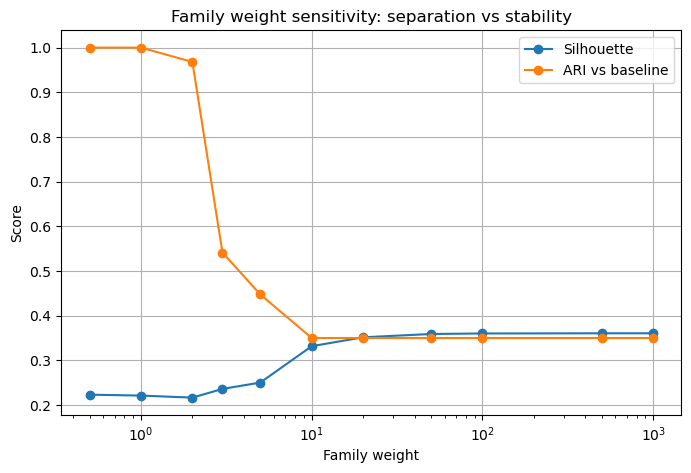

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    family_weight_stability["weight"],
    family_weight_stability["silhouette_score"],
    marker="o",
    label="Silhouette"
)
plt.plot(
    family_weight_stability["weight"],
    family_weight_stability["ari_vs_baseline"],
    marker="o",
    label="ARI vs baseline"
)

plt.xscale("log")
plt.xlabel("Family weight")
plt.ylabel("Score")
plt.title("Family weight sensitivity: separation vs stability")
plt.legend()
plt.grid(True)
plt.show()

#### Selected family-weight solution

Based on the weight sensitivity analysis, a family weight of 10 is used for the detailed clustering test. At this point, family-related features clearly reshape the clustering structure and the silhouette score has already entered the high-performance plateau.

The next step is to evaluate which value of `k` produces the most interpretable family-oriented segmentation.

In [33]:
family_weight = 10.0

In [34]:
family_k_values = [2, 3, 4, 5, 6]

X_family, family_results = run_group_weighted_kmeans_diagnostics(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="family",
    weight=family_weight,
    k_values=family_k_values,
)

display(family_results.sort_values("silhouette_score", ascending=False))

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,kmeans,2,0.453515,1.337915,30.509041
1,kmeans,3,0.331405,1.068404,33.213037
3,kmeans,5,0.262210,1.086407,35.891196
2,kmeans,4,0.252355,1.136153,34.543707
4,kmeans,6,0.228152,1.122957,33.793667


In [35]:
family_k = 2

KMeans solution for k=2
Average silhouette score: 0.454


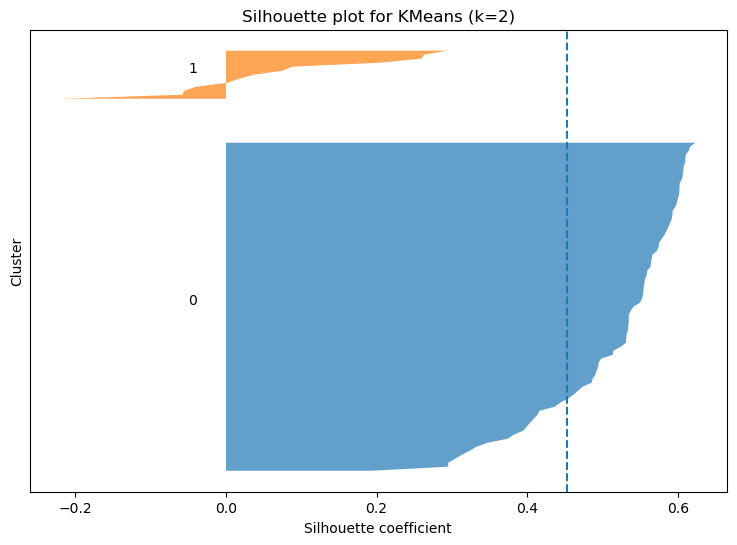

Cluster sizes


,cluster,n_neighborhoods
0,0,83
1,1,13


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1093.223,0.006,0.057,8.020,0.135,1.451,0.359,3.082,0.259,0.003,0.137,0.281,0.443,2.856,2.412,0.366,1.202,3.817,0.244,4.605,0.183,0.324,0.204,1954.113,449.740,1.075,0.094,0.195,3.008,1.175,0.075,1.619,3.468,2.515,2.375,0.0,2.144,0.438,1.42,0.482,1.234,0.200,11.651,0.192,9237.746,0.048,0.005,0.345,0.587,0.276,0.028,6.414,0.721,1308.345,839.564,324.457,962.350,690.757,1036.631,426.161,362.284,994.638,332.637,581.54,1341.714,660.244,1341.628,1815.114,1240.119,859.135,1075.748,1997.286,599.055,744.693,1587.494,1968.256,2349.398,2390.754,1991.382,1938.614,454.481,1790.021,1616.966,2233.063
1,1818.712,0.002,0.003,1.923,0.000,0.038,0.089,0.102,0.080,0.000,0.063,0.003,0.003,0.180,0.112,0.037,0.162,0.384,0.014,0.599,0.000,0.041,0.000,385.881,105.482,0.059,0.008,0.136,0.175,0.130,0.007,0.254,0.533,0.435,0.048,0.0,0.135,0.007,0.20,0.026,0.041,0.004,0.768,0.014,2822.208,0.059,0.001,0.034,0.848,0.576,0.024,3.270,1.266,3622.927,2717.501,797.315,3231.674,2234.256,2407.631,1112.132,1079.426,2864.605,1369.040,1815.66,4232.375,2193.098,2776.875,4341.999,3649.031,1623.980,1757.323,4862.587,2020.865,2532.389,4252.381,4832.455,4980.964,5723.163,4538.312,2162.043,1174.485,4067.154,4107.395,4474.322


Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.14,0.11,0.06,0.22,0.08,0.07,0.04,0.07,0.10,0.01,0.06,0.10,0.06,0.14,0.13,0.10,0.07,0.13,0.09,0.10,0.09,0.05,0.05,0.22,0.22,0.14,0.07,0.03,0.08,0.14,0.04,0.15,0.05,0.11,0.09,0,0.15,0.08,0.10,0.08,0.08,0.05,0.08,0.1,0.22,-0.03,0.18,0.03,-0.12,-0.12,0.02,0.05,-0.06,-0.26,-0.29,-0.23,-0.28,-0.26,-0.19,-0.26,-0.27,-0.26,-0.32,-0.28,-0.22,-0.31,-0.14,-0.24,-0.25,-0.17,-0.13,-0.22,-0.29,-0.28,-0.23,-0.25,-0.20,-0.25,-0.18,-0.03,-0.22,-0.18,-0.25,-0.17
1,0.89,-0.82,-0.35,-1.38,-0.51,-0.46,-0.24,-0.47,-0.66,-0.12,-0.41,-0.67,-0.39,-0.88,-0.81,-0.62,-0.46,-0.83,-0.55,-0.63,-0.59,-0.34,-0.34,-1.41,-1.43,-0.93,-0.48,-0.21,-0.52,-0.87,-0.28,-0.97,-0.29,-0.70,-0.58,0,-0.96,-0.54,-0.62,-0.54,-0.49,-0.31,-0.54,-0.6,-1.43,0.14,-0.83,-0.21,0.75,0.74,-0.09,-0.34,0.39,1.64,1.87,1.48,1.77,1.64,1.19,1.64,1.73,1.69,2.06,1.80,1.43,1.98,0.91,1.50,1.62,1.06,0.84,1.42,1.87,1.76,1.44,1.60,1.28,1.60,1.17,0.18,1.44,1.18,1.57,1.10


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,bus_stop_count_per_sq_km,0.22,0,higher
1,parking_space_count_per_sq_km,0.22,0,higher
2,parking_capacity_per_sq_km,0.22,0,higher
3,bike_lane_length_m_per_sq_km,0.22,0,higher
4,playground_share,0.18,0,higher
5,supermarket_count_per_sq_km,0.15,0,higher
6,school_count_per_sq_km,0.15,0,higher
7,gas_station_count_per_sq_km,0.14,0,higher
8,pharmacy_count_per_sq_km,0.14,0,higher
9,religious_institution_count_per_sq_km,0.14,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k2
0,Charlottenburg,Charlottenburg-Wilmersdorf,0
1,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0
2,Halensee,Charlottenburg-Wilmersdorf,0
3,Schmargendorf,Charlottenburg-Wilmersdorf,0
4,Westend,Charlottenburg-Wilmersdorf,0
5,Wilmersdorf,Charlottenburg-Wilmersdorf,0
6,Friedrichshain,Friedrichshain-Kreuzberg,0
7,Kreuzberg,Friedrichshain-Kreuzberg,0
8,Alt-Hohenschönhausen,Lichtenberg,0
9,Falkenberg,Lichtenberg,0


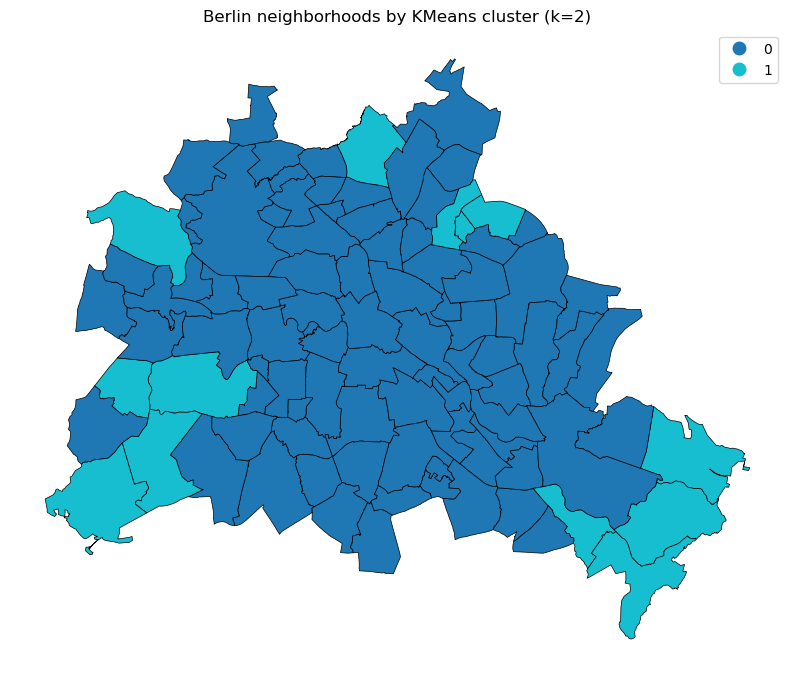

In [36]:
results_family_k = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_family,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=family_k,
)

#### Interpreting the family-oriented solution

The weight sensitivity analysis shows that family-related features have a limited influence on the baseline clustering structure at low weights.

At weights up to approximately 2, clustering remains almost identical to the baseline, with silhouette scores close to the original solution and adjusted Rand index near 1. This indicates that family-related variables are not strongly aligned with the dominant urban structure of the city.

A transition phase occurs between weights 3 and 5, where cluster assignments begin to change and the adjusted Rand index drops significantly. This marks the point at which family-related features start to meaningfully influence neighborhood similarity.

At weights of 10 and above, a new stable clustering regime emerges. Silhouette scores increase substantially and then plateau, while similarity to the baseline remains low. This indicates that family-related features are now the dominant driver of clustering.

At the selected weight of 10 and k = 2, the clustering produces a clear binary structure:

- a large cluster of 83 neighborhoods  
- a smaller cluster of 13 neighborhoods  

The average silhouette score of approximately 0.45 indicates strong separation.

Two distinct neighborhood types emerge:

- **Cluster 0: broadly family-compatible urban fabric**  
  This cluster includes the majority of Berlin neighborhoods. It is characterized by:
  - moderate to high availability of schools, supermarkets, and services  
  - relatively short distances to everyday amenities  
  - balanced accessibility and infrastructure  

  In practice, this cluster represents areas where family-related needs are reasonably well met within a typical urban environment.

- **Cluster 1: low-access, peripheral family environments**  
  This smaller cluster captures highly peripheral neighborhoods. It is characterized by:
  - very low densities of services and infrastructure  
  - long distances to schools, playgrounds, and everyday amenities  
  - lower accessibility overall  

  These neighborhoods are structurally less compatible with family-oriented needs, despite often having higher park or open-space shares.

The family-oriented clustering does not produce a fine-grained segmentation of “family-friendly” neighborhoods.

Instead, it creates a **strong contrast between accessible urban areas and remote peripheral areas**.

This suggests that:

- family-related features primarily act as a **filter**, not a nuanced segmentation dimension  
- the dominant distinction is not between different types of family neighborhoods, but between:
  - neighborhoods where services are reachable  
  - neighborhoods where they are not  

#### Best-matching cluster for family preferences

In [37]:
family_cluster_scores, family_best_cluster, _ = rank_clusters_for_preference(
    df_with_clusters=results_family_k["df_result"],
    cluster_col=f"cluster_kmeans_k{family_k}",
    X_original=X_imputed,
    preference_features=group_feature_map["family"],
)

Preference features used for scoring:


,feature
0,kindergarten_count_per_1000
1,school_count_per_1000
2,kindergarten_capacity_per_1000
3,playground_share
4,avg_dist_3_school_m
5,avg_dist_3_playground_m


Cluster ranking for this preference scenario:


cluster_kmeans_k2
0    0.095421
1   -0.609224
dtype: float64

Best-matching cluster: 0


The preference-based scoring confirms this interpretation.

- **Cluster 0** achieves the highest score for family-related features  
- **Cluster 1** scores substantially lower  

This indicates that, under a family-oriented preference profile, the majority of Berlin neighborhoods are relatively suitable, while a smaller set of peripheral areas is clearly less aligned with these needs.

#### Family-oriented takeaway

Family-related features require strong weighting to influence clustering and do not define a natural segmentation of the city on their own.

When amplified, they primarily separate:

- **accessible, service-rich neighborhoods**  
- **low-access peripheral areas**

Rather than revealing multiple distinct family-oriented neighborhood types, this dimension reinforces the importance of proximity and accessibility for family life in an urban context.

### G2. Nightlife-oriented clustering

This profile emphasizes features related to:

- venues  
- cinemas and theaters  
- social clubs  
- spaetis  
- transport access for late-hour activity  

The goal is to evaluate whether nightlife and entertainment infrastructure define a strong and separable dimension in the city, and how it compares to the family-oriented signal.

#### Weight sensitivity

In [38]:
weight_values = [0.5, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 500, 1000]
nightlife_weight_for_sensitivity_k = 3

nightlife_weight_stability = weight_stability_analysis(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="nightlife",
    weight_values=weight_values,
    k=nightlife_weight_for_sensitivity_k,
)

display(nightlife_weight_stability)

,weight,silhouette_score,ari_vs_baseline
0,0.5,0.217768,0.937058
1,1.0,0.220784,1.000000
2,2.0,0.247371,0.768162
3,3.0,0.256029,0.707301
4,5.0,0.283179,0.707301
5,10.0,0.381058,0.467751
6,20.0,0.451134,0.359370
7,30.0,0.509596,0.325984
8,40.0,0.512194,0.325984
9,50.0,0.513442,0.325984


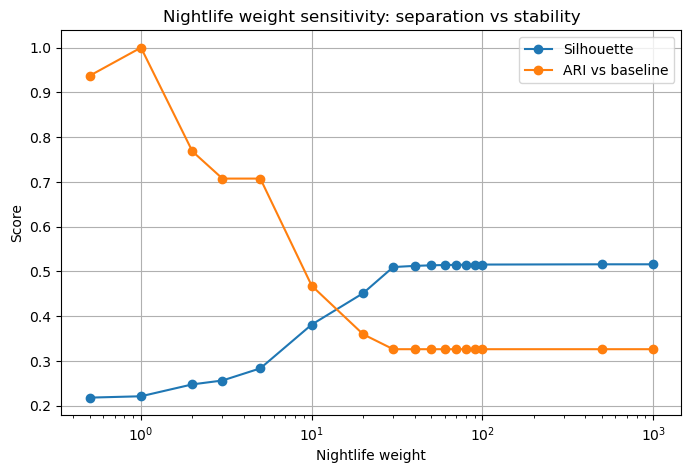

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    nightlife_weight_stability["weight"],
    nightlife_weight_stability["silhouette_score"],
    marker="o",
    label="Silhouette"
)
plt.plot(
    nightlife_weight_stability["weight"],
    nightlife_weight_stability["ari_vs_baseline"],
    marker="o",
    label="ARI vs baseline"
)

plt.xscale("log")
plt.xlabel("Nightlife weight")
plt.ylabel("Score")
plt.title("Nightlife weight sensitivity: separation vs stability")
plt.legend()
plt.grid(True)
plt.show()

#### Selected nightlife-weight solution

Based on the weight sensitivity analysis, a nightlife weight of 20 is selected. At this level, the clustering structure has already transitioned away from the baseline and reached a stable regime with high separation.

The next step is to evaluate which number of clusters best captures this nightlife-driven structure.

In [40]:
nightlife_weight = 20.0

In [41]:
nightlife_k_values = [2, 3, 4, 5, 6]

X_nightlife, nightlife_results = run_group_weighted_kmeans_diagnostics(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="nightlife",
    weight=nightlife_weight,
    k_values=nightlife_k_values,
)

display(nightlife_results.sort_values("silhouette_score", ascending=False))

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,kmeans,2,0.609978,0.783551,90.430296
2,kmeans,4,0.456178,0.873907,86.910086
1,kmeans,3,0.451134,0.773131,81.404138
4,kmeans,6,0.343140,0.902505,85.384751
3,kmeans,5,0.339541,0.910255,83.271270


In [42]:
nightlife_k = 2

KMeans solution for k=2
Average silhouette score: 0.610


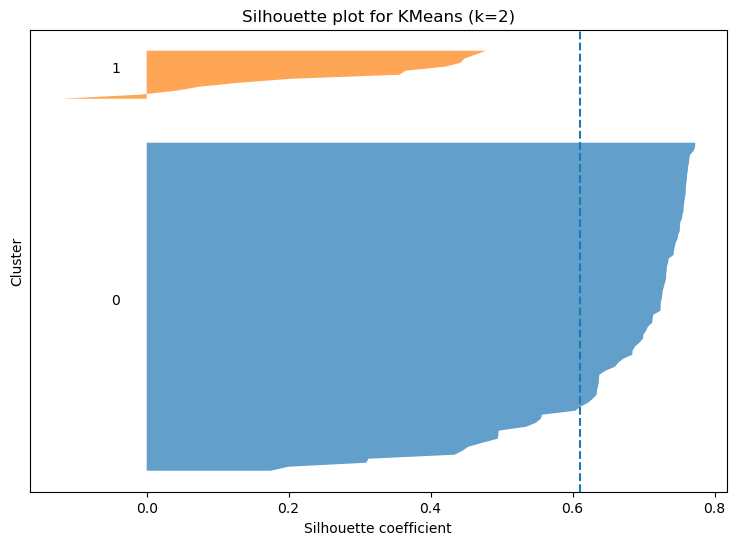

Cluster sizes


,cluster,n_neighborhoods
0,0,83
1,1,13


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1206.748,0.005,0.031,6.541,0.046,0.673,0.246,1.567,0.182,0.003,0.117,0.154,0.106,1.795,1.416,0.246,0.522,2.324,0.159,2.414,0.136,0.131,0.047,1549.398,376.083,0.676,0.047,0.170,2.069,0.734,0.048,1.170,2.889,1.395,0.866,0.0,1.354,0.176,0.999,0.305,0.483,0.136,4.352,0.106,7696.457,0.044,0.003,0.306,0.601,0.329,0.025,5.876,0.738,1821.318,1215.435,402.260,1411.164,993.403,1327.592,563.397,490.462,1370.153,514.555,799.146,1965.058,945.140,1686.605,2370.449,1712.302,1024.774,1206.436,2637.658,865.542,1088.320,2170.953,2568.096,2913.122,3057.968,2560.246,2119.119,587.877,2357.357,2125.168,2797.269
1,1093.902,0.012,0.165,11.364,0.565,5.007,0.814,9.779,0.568,0.000,0.197,0.814,2.159,6.954,6.469,0.806,4.507,9.915,0.554,14.588,0.300,1.272,1.004,2969.833,575.752,2.605,0.310,0.295,6.170,2.946,0.181,3.119,4.231,7.587,9.687,0.0,5.174,1.686,2.886,1.160,4.834,0.408,47.370,0.558,12662.750,0.084,0.009,0.287,0.753,0.239,0.042,6.708,1.158,347.794,317.709,300.576,366.172,301.981,549.957,235.936,261.053,467.087,207.564,426.335,252.564,374.148,574.328,796.403,634.327,566.443,922.931,774.056,319.453,338.461,527.219,1002.711,1381.805,1463.262,906.330,1009.588,322.805,444.932,862.721,872.084


Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.02,-0.12,-0.14,-0.17,-0.31,-0.22,-0.08,-0.20,-0.23,0.01,-0.07,-0.25,-0.29,-0.27,-0.28,-0.16,-0.27,-0.29,-0.15,-0.30,-0.08,-0.21,-0.25,-0.20,-0.13,-0.28,-0.23,-0.07,-0.12,-0.29,-0.08,-0.22,-0.02,-0.33,-0.34,0,-0.29,-0.30,-0.15,-0.16,-0.28,-0.07,-0.33,-0.24,-0.17,-0.09,-0.33,0.00,-0.07,0.03,-0.06,-0.01,-0.05,0.16,0.14,0.05,0.13,0.12,0.11,0.12,0.09,0.13,0.10,0.09,0.13,0.12,0.11,0.15,0.11,0.10,0.05,0.14,0.11,0.12,0.14,0.14,0.12,0.12,0.12,0.14,0.08,0.16,0.12,0.15
1,-0.14,1.50,0.88,1.09,1.95,1.40,0.50,1.29,1.43,-0.12,0.45,1.59,1.83,1.70,1.77,1.06,1.75,1.83,0.95,1.91,0.53,1.37,1.58,1.28,0.83,1.76,1.48,0.44,0.76,1.84,0.54,1.38,0.13,2.10,2.19,0,1.83,1.89,0.95,1.02,1.80,0.42,2.12,1.52,1.11,0.51,1.19,-0.01,0.44,-0.22,0.39,0.09,0.30,-1.04,-0.90,-0.32,-0.81,-0.74,-0.68,-0.78,-0.55,-0.81,-0.61,-0.54,-0.85,-0.74,-0.71,-0.94,-0.73,-0.64,-0.35,-0.92,-0.72,-0.74,-0.89,-0.88,-0.74,-0.77,-0.76,-0.87,-0.53,-0.99,-0.80,-0.95


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,avg_dist_5_atm_m,0.16,0,higher
1,avg_dist_3_transport_station_entrance_m,0.16,0,higher
2,avg_dist_5_transport_station_m,0.15,0,higher
3,avg_dist_3_vocational_school_m,0.15,0,higher
4,avg_dist_3_food_market_m,0.14,0,higher
5,avg_dist_3_pool_m,0.14,0,higher
6,avg_dist_3_library_m,0.14,0,higher
7,avg_dist_3_government_office_m,0.14,0,higher
8,avg_dist_5_bakery_m,0.14,0,higher
9,avg_dist_5_spaeti_m,0.13,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k2
0,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0
1,Grunewald,Charlottenburg-Wilmersdorf,0
2,Halensee,Charlottenburg-Wilmersdorf,0
3,Schmargendorf,Charlottenburg-Wilmersdorf,0
4,Westend,Charlottenburg-Wilmersdorf,0
5,Alt-Hohenschönhausen,Lichtenberg,0
6,Falkenberg,Lichtenberg,0
7,Fennpfuhl,Lichtenberg,0
8,Friedrichsfelde,Lichtenberg,0
9,Karlshorst,Lichtenberg,0


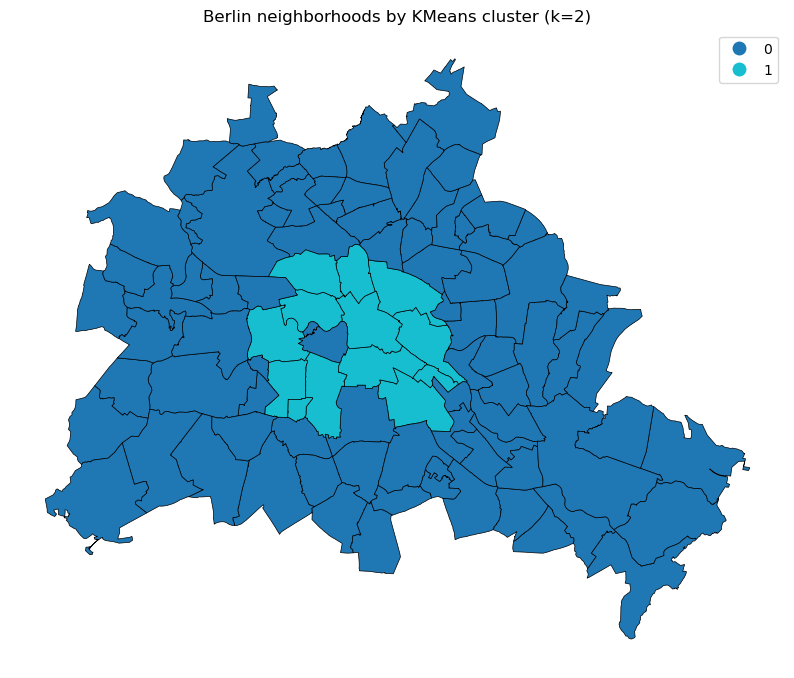

In [43]:
results_nightlife_k = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_nightlife,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=nightlife_k,
)

#### Interpreting the nightlife-oriented solution

The weight sensitivity analysis shows that nightlife-related features reshape the clustering structure much more strongly than family-related features.

Even at moderate weights, nightlife begins to pull neighborhoods away from the baseline solution. The adjusted Rand index drops steadily as the weight increases, while silhouette scores rise sharply. This indicates that nightlife is not a weak secondary signal, but a highly discriminative urban dimension.

A clear transition occurs between weights 10 and 30. In this range:

- clustering becomes substantially more separated  
- similarity to the baseline drops sharply  
- the resulting structure stabilizes into a new regime  

Beyond roughly 30, silhouette scores plateau and the adjusted Rand index no longer changes meaningfully. This indicates that nightlife-related structure has fully emerged and further weighting adds little.

At the selected weight of 20 and k = 2, the clustering produces a very strong binary structure:

- a large cluster of 83 neighborhoods  
- a smaller cluster of 13 neighborhoods  

The average silhouette score of approximately 0.61 indicates very strong separation.

This is a much cleaner and more decisive split than in the baseline solution.

Two distinct neighborhood types emerge:

- **Cluster 1: nightlife-intensive urban core**  
  This smaller cluster captures the most nightlife-oriented parts of Berlin. It is characterized by:
  - very high densities of spaetis, venues, social clubs, theaters, cinemas, and night clubs  
  - short distances to late-hour infrastructure and transport access  
  - strong concentration of activity, accessibility, and central-city functions  

  This cluster corresponds to the central nightlife and entertainment core of the city.

- **Cluster 0: non-nightlife majority city fabric**  
  This large cluster contains the rest of Berlin. It is characterized by:
  - lower densities of nightlife and entertainment infrastructure  
  - longer distances to spaetis, transport access, and cultural venues  
  - a more residential, peripheral, or mixed-use urban character  

  In practice, this cluster represents neighborhoods where nightlife is not a defining feature of the local urban environment.

Unlike family-oriented clustering, nightlife produces a highly coherent and naturally separable urban pattern.

This suggests that nightlife is not simply one preference among many, but a major structural axis in the city.

When amplified, nightlife-related features do not create a subtle re-ranking of neighborhoods. They generate a clear contrast between:

- a compact, activity-dense nightlife core  
- the broader city outside that core  

#### Best-matching cluster for nightlife preferences

In [44]:
nightlife_cluster_scores, nightlife_best_cluster, _ = rank_clusters_for_preference(
    df_with_clusters=results_nightlife_k["df_result"],
    cluster_col=f"cluster_kmeans_k{nightlife_k}",
    X_original=X_imputed,
    preference_features=group_feature_map["nightlife"],
)

Preference features used for scoring:


,feature
0,venue_count_per_sq_km
1,spaeti_count_per_sq_km
2,social_club_count_per_sq_km
3,theater_count_per_sq_km
4,cinema_count_per_sq_km
5,night_club_count_per_sq_km
6,avg_dist_5_spaeti_m
7,avg_dist_5_transport_station_m


Cluster ranking for this preference scenario:


cluster_kmeans_k2
1    1.701579
0   -0.266512
dtype: float64

Best-matching cluster: 1


The preference-based scoring confirms this interpretation.

- **Cluster 1** achieves by far the highest score for nightlife-related features  
- **Cluster 0** scores substantially lower  

This indicates that the nightlife-oriented profile identifies a compact set of neighborhoods that are strongly aligned with entertainment, late-hour accessibility, and central-city activity.

#### Nightlife-oriented takeaway

Nightlife-related features are the strongest user-intent signal tested in this section.

They require less forcing than family-related features and produce a much sharper clustering structure. When weighted strongly, they isolate a clear nightlife-oriented urban core from the rest of the city.

This makes nightlife a particularly powerful dimension for user-driven neighborhood similarity and recommendation.

### G3. Transport-oriented clustering

This profile emphasizes features related to:

- bus stops  
- tram stops  
- transport stations  
- bike lane infrastructure  
- distance to public transport  

The goal is to test whether neighborhoods reorganize meaningfully when mobility and accessibility are prioritized, and whether this dimension aligns with or diverges from the baseline clustering.

#### Weight sensitivity

In [45]:
weight_values = [0.5, 1, 2, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 500, 1000]
transport_weight_for_sensitivity_k = 3

transport_weight_stability = weight_stability_analysis(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="transport",
    weight_values=weight_values,
    k=transport_weight_for_sensitivity_k,
)

display(transport_weight_stability)

,weight,silhouette_score,ari_vs_baseline
0,0.5,0.219697,1.000000
1,1.0,0.220784,1.000000
2,2.0,0.244684,0.834602
3,3.0,0.245913,0.805630
4,5.0,0.249694,0.688967
5,10.0,0.313804,0.589397
6,20.0,0.331266,0.571253
7,30.0,0.328710,0.519982
8,40.0,0.329766,0.519982
9,50.0,0.330263,0.519982


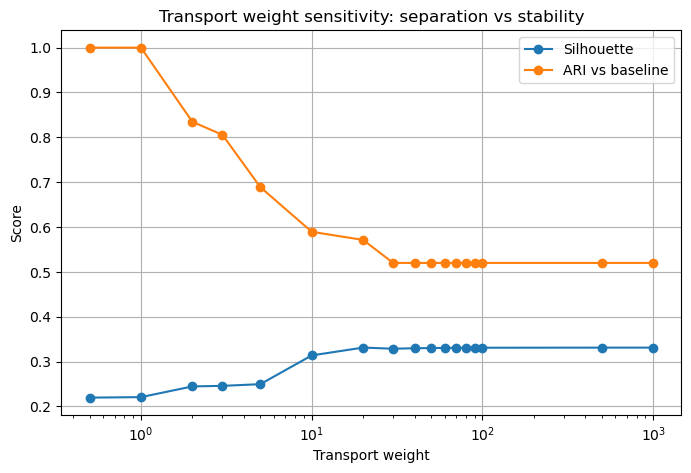

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    transport_weight_stability["weight"],
    transport_weight_stability["silhouette_score"],
    marker="o",
    label="Silhouette"
)
plt.plot(
    transport_weight_stability["weight"],
    transport_weight_stability["ari_vs_baseline"],
    marker="o",
    label="ARI vs baseline"
)

plt.xscale("log")
plt.xlabel("Transport weight")
plt.ylabel("Score")
plt.title("Transport weight sensitivity: separation vs stability")
plt.legend()
plt.grid(True)
plt.show()

#### Selected transport-weight solution

Based on the weight sensitivity analysis, a transport weight of 10 is selected. At this level, clustering begins to meaningfully diverge from the baseline while still maintaining a stable structure.

The next step is to determine the appropriate number of clusters for this transport-oriented feature space.

In [47]:
transport_weight = 10.0

In [48]:
transport_k_values = [2, 3, 4, 5, 6]

X_transport, transport_results = run_group_weighted_kmeans_diagnostics(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    target_group="transport",
    weight=transport_weight,
    k_values=transport_k_values,
)

display(transport_results.sort_values("silhouette_score", ascending=False))

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
1,kmeans,3,0.313804,1.144853,41.363883
0,kmeans,2,0.300705,1.243047,43.455966
3,kmeans,5,0.243626,1.325027,34.706694
2,kmeans,4,0.240650,1.235988,37.481842
4,kmeans,6,0.229296,1.306837,32.222047


In [49]:
transport_k = 3

KMeans solution for k=3
Average silhouette score: 0.314


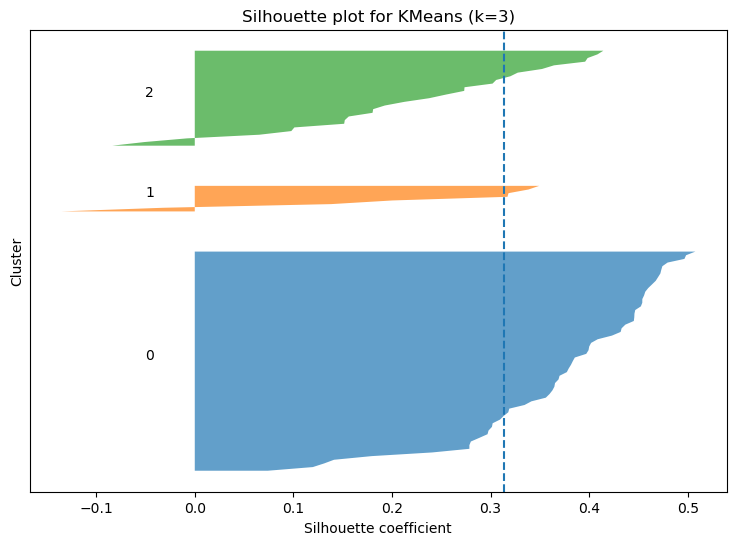

Cluster sizes


,cluster,n_neighborhoods
0,0,61
1,1,8
2,2,27


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1036.053,0.006,0.066,8.354,0.100,1.145,0.317,2.503,0.241,0.004,0.128,0.223,0.253,2.746,2.256,0.389,0.816,3.575,0.209,3.983,0.205,0.225,0.121,2007.030,455.639,1.034,0.095,0.200,2.833,1.072,0.077,1.648,3.697,2.355,2.066,0.0,2.083,0.304,1.419,0.374,0.809,0.176,8.310,0.165,9465.304,0.054,0.005,0.440,0.571,0.281,0.024,6.905,0.664,1156.536,735.717,285.643,849.566,598.896,942.113,394.101,315.600,860.282,289.077,535.028,1094.551,595.222,1136.155,1583.331,1164.014,867.866,1119.635,1743.104,502.570,610.472,1345.837,1809.997,2057.492,2254.116,1724.160,1864.360,395.263,1524.228,1459.418,2123.879
1,1215.281,0.013,0.085,12.574,0.593,5.973,1.267,12.073,0.470,0.000,0.149,1.129,2.620,7.863,7.219,0.724,5.746,10.606,0.857,15.023,0.278,1.612,1.197,3188.411,648.485,2.830,0.221,0.274,8.941,3.261,0.165,3.495,6.876,7.304,8.656,0.0,5.261,2.145,3.012,2.062,6.575,0.718,55.002,0.636,14699.891,0.053,0.009,0.191,0.757,0.263,0.046,2.740,1.090,376.472,351.390,249.696,448.854,306.038,527.818,263.597,185.519,519.130,189.874,371.568,264.539,417.327,541.509,671.294,633.354,487.914,726.040,647.593,295.366,334.505,552.509,890.478,1446.668,1386.478,962.270,891.634,281.673,316.916,725.807,736.885
2,1535.529,0.003,0.002,2.980,0.012,0.123,0.054,0.293,0.151,0.000,0.120,0.030,0.015,0.335,0.232,0.050,0.227,0.699,0.030,0.995,0.017,0.030,0.001,713.767,211.771,0.157,0.013,0.133,0.281,0.288,0.012,0.340,0.527,0.456,0.094,0.0,0.389,0.030,0.363,0.039,0.036,0.005,1.117,0.034,4016.258,0.039,0.001,0.029,0.697,0.414,0.030,4.881,1.002,3041.861,2123.017,661.973,2461.944,1755.452,2061.041,877.043,865.418,2339.430,972.361,1343.044,3611.083,1617.161,2733.962,3894.331,2751.690,1317.661,1408.379,4351.047,1591.

Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.22,0.11,0.13,0.30,-0.07,-0.04,-0.01,-0.03,0.03,0.05,0.00,-0.06,-0.13,0.10,0.06,0.15,-0.12,0.06,-0.01,-0.01,0.18,-0.08,-0.11,0.28,0.25,0.10,0.08,0.05,0.04,0.04,0.05,0.18,0.07,0.05,0.00,0,0.12,-0.11,0.10,-0.06,-0.13,0.01,-0.11,-0.01,0.28,0.06,0.18,0.11,-0.17,-0.10,-0.09,0.11,-0.11,-0.38,-0.41,-0.37,-0.38,-0.37,-0.28,-0.35,-0.40,-0.40,-0.42,-0.36,-0.36,-0.41,-0.29,-0.40,-0.31,-0.15,-0.07,-0.37,-0.44,-0.43,-0.38,-0.35,-0.36,-0.33,-0.33,-0.09,-0.36,-0.34,-0.36,-0.23
1,0.03,1.73,0.27,1.41,2.07,1.77,0.97,1.71,1.01,-0.12,0.14,2.48,2.30,2.05,2.08,0.88,2.38,2.02,1.78,1.99,0.45,1.84,1.95,1.50,1.18,1.99,0.90,0.36,1.35,2.14,0.46,1.69,0.44,1.99,1.89,0,1.88,2.56,1.03,2.26,2.64,0.99,2.55,1.82,1.63,0.05,1.19,-0.09,0.45,-0.15,0.49,-0.41,0.24,-1.02,-0.86,-0.50,-0.74,-0.73,-0.70,-0.71,-0.77,-0.76,-0.65,-0.64,-0.84,-0.67,-0.73,-1.02,-0.73,-0.76,-0.63,-1.00,-0.76,-0.74,-0.87,-0.95,-0.71,-0.81,-0.73,-0.98,-0.62,-1.07,-0.90,-1.02
2,0.49,-0.59,-0.36,-1.11,-0.45,-0.43,-0.28,-0.43,-0.36,-0.12,-0.05,-0.60,-0.38,-0.82,-0.76,-0.59,-0.42,-0.74,-0.51,-0.56,-0.53,-0.35,-0.34,-1.07,-0.92,-0.82,-0.45,-0.22,-0.50,-0.72,-0.25,-0.90,-0.29,-0.70,-0.56,0,-0.82,-0.51,-0.52,-0.53,-0.50,-0.30,-0.52,-0.52,-1.12,-0.16,-0.83,-0.22,0.25,0.28,0.07,-0.14,0.17,1.16,1.19,0.99,1.07,1.05,0.84,0.99,1.14,1.14,1.15,1.00,1.07,1.12,0.88,1.20,0.92,0.57,0.34,1.13,1.22,1.19,1.11,1.08,1.03,0.98,0.95,0.50,1.00,1.09,1.08,0.83


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,bus_stop_count_per_sq_km,0.30,0,higher
1,bike_lane_length_m_per_sq_km,0.28,0,higher
2,parking_capacity_per_sq_km,0.28,0,higher
3,parking_space_count_per_sq_km,0.25,0,higher
4,school_count_per_sq_km,0.18,0,higher
5,playground_share,0.18,0,higher
6,mall_count_per_sq_km,0.18,0,higher
7,hospital_count_per_sq_km,0.15,0,higher
8,bouldering_spot_count_per_sq_km,0.13,0,higher
9,supermarket_count_per_sq_km,0.12,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k3
0,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0
1,Halensee,Charlottenburg-Wilmersdorf,0
2,Schmargendorf,Charlottenburg-Wilmersdorf,0
3,Westend,Charlottenburg-Wilmersdorf,0
4,Alt-Hohenschönhausen,Lichtenberg,0
5,Fennpfuhl,Lichtenberg,0
6,Friedrichsfelde,Lichtenberg,0
7,Karlshorst,Lichtenberg,0
8,Lichtenberg,Lichtenberg,0
9,Neu-Hohenschönhausen,Lichtenberg,0


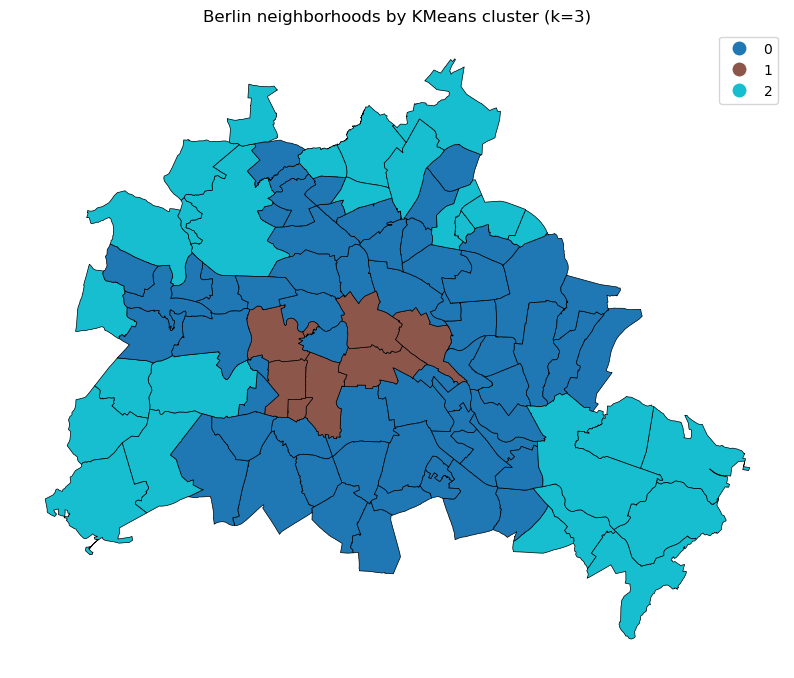

In [50]:
results_transport_k = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_transport,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=transport_k,
)

#### Interpreting the transport-oriented solution

The weight sensitivity analysis shows that transport-related features reshape clustering more gradually than nightlife, but more clearly than family-related features at low weights.

At weights up to approximately 5, the clustering remains broadly similar to the baseline, although separation improves modestly and the adjusted Rand index declines steadily. This indicates that transport is already partly embedded in the dominant city structure, rather than acting as a completely independent signal.

A clearer transition appears between weights 10 and 20. In this range:

- silhouette scores increase meaningfully  
- similarity to the baseline decreases  
- the clustering stabilizes into a new but still recognizably related structure  

Beyond roughly 20, both the silhouette score and the adjusted Rand index plateau. This indicates that transport-related structure has been fully activated and further weighting adds little.

At the selected weight of 10 and k = 3, the clustering produces a clear three-part structure:

- a large cluster of 61 neighborhoods  
- a small cluster of 8 neighborhoods  
- a medium-sized cluster of 27 neighborhoods  

The average silhouette score of approximately 0.31 indicates meaningful separation, though not as sharply binary as the nightlife-oriented solution.

This suggests that transport does not split the city into just “well connected” and “poorly connected” areas. Instead, it reveals a layered structure with three different levels of connectivity.

Three distinct neighborhood types emerge:

- **Cluster 1: highly connected transport core**  
  This small cluster captures the most transport-rich parts of the city. It is characterized by:
  - very high counts of transport station entrances, transport stations, and tram infrastructure  
  - very short distances to transport nodes  
  - high bike lane density  
  - strong overlap with dense central areas and highly connected urban corridors  

  This cluster represents the most mobility-intensive and well-connected neighborhoods in Berlin.

- **Cluster 0: accessible intermediate belt**  
  This large cluster represents neighborhoods with solid overall transport access but without the extreme concentration of the transport core. It is characterized by:
  - above-average bus stop density  
  - relatively good access to transport and services  
  - balanced infrastructure and moderate accessibility  

  This cluster can be interpreted as a broad belt of reasonably well-connected urban neighborhoods.

- **Cluster 2: peripheral low-connectivity belt**  
  This cluster captures the least connected neighborhoods. It is characterized by:
  - low bus stop density  
  - low bike lane density  
  - longer distances to transport stations, bus stops, and tram stops  
  - strong concentration in the outer and more peripheral parts of the city  

  This cluster represents the lowest-connectivity segment of Berlin’s neighborhood space.

Unlike nightlife, transport does not create a sharply isolated urban core versus everything else.

Instead, it produces a more graded structure with:

- a highly connected transport core  
- a broad intermediate connected belt  
- a peripheral low-connectivity outer belt  

This suggests that transport accessibility is both:

- a meaningful independent preference dimension  
- and partly aligned with the baseline accessibility and urban intensity structure

In other words, weighting transport does not overturn the baseline logic of the city. It refines it.

#### Best-matching cluster for transport preferences

In [51]:
transport_cluster_scores, transport_best_cluster, _ = rank_clusters_for_preference(
    df_with_clusters=results_transport_k["df_result"],
    cluster_col=f"cluster_kmeans_k{transport_k}",
    X_original=X_imputed,
    preference_features=group_feature_map["transport"],
)

Preference features used for scoring:


,feature
0,bus_stop_count_per_sq_km
1,tram_stop_count_per_sq_km
2,transport_station_count_per_sq_km
3,transport_station_entrance_count_per_sq_km
4,bike_lane_length_m_per_sq_km
5,avg_dist_5_transport_station_m
6,avg_dist_5_bus_stop_m
7,avg_dist_5_tram_stop_m


Cluster ranking for this preference scenario:


cluster_kmeans_k3
1    1.403500
0    0.194467
2   -0.855203
dtype: float64

Best-matching cluster: 1


The preference-based scoring confirms this interpretation.

- **Cluster 1** achieves the highest score for transport-related features  
- **Cluster 0** also scores positively, though much lower  
- **Cluster 2** scores clearly worst  

This means that transport preferences do not identify just one “good vs bad” split. They reveal a gradient:

- the best connected neighborhoods  
- a second tier of still-accessible neighborhoods  
- and a clearly weaker peripheral tier

#### Transport-oriented takeaway

Transport-related features strengthen an accessibility structure that is already present in the data.

When weighted, they produce a more explicit three-level transport hierarchy rather than a completely new segmentation of the city.

This makes transport a strong but baseline-compatible user-intent dimension: it meaningfully reshapes clustering, but largely by sharpening an existing urban gradient rather than replacing it.

### G4. Continuous user-weighted feature space

#### Scenario setup

The previous sections use fixed thematic profiles with a single dominant preference.

In practice, users balance multiple priorities simultaneously.

To simulate this, feature groups can be weighted continuously, similar to user-controlled sliders.

For example:

- family = 10.0  
- nightlife = -5.0  
- transport = 5.0  

This approach does not yet constitute a full recommendation system, but it approximates how user-defined similarity could be modeled.

It allows clustering to reflect **combinations of preferences**, rather than a single dominant dimension.

In [52]:
# -----------------------------------
# Composite user-intent scenario
# -----------------------------------

composite_weights = {
    "family": 10.0,
    "transport": 5.0,
    "nightlife": -5.0,
}

In [53]:
X_composite = apply_group_weights(
    X_scaled=X_scaled,
    feature_cols=feature_cols,
    group_feature_map=group_feature_map,
    group_weights=composite_weights,
)

#### Selected composite solution

The composite feature space is evaluated across multiple values of k to determine the most appropriate clustering structure under combined user preferences.

In [54]:
composite_k_values = [2, 3, 4, 5, 6]

composite_results = evaluate_kmeans(X_composite, composite_k_values)

display(composite_results.sort_values("silhouette_score", ascending=False))

,model,k,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,kmeans,2,0.371900,1.151801,54.809100
1,kmeans,3,0.253770,1.288085,43.980108
2,kmeans,4,0.237839,1.341999,39.411985
3,kmeans,5,0.230682,1.189390,38.362460
4,kmeans,6,0.216314,1.232451,34.718065


In [55]:
composite_k = 2

KMeans solution for k=2
Average silhouette score: 0.372


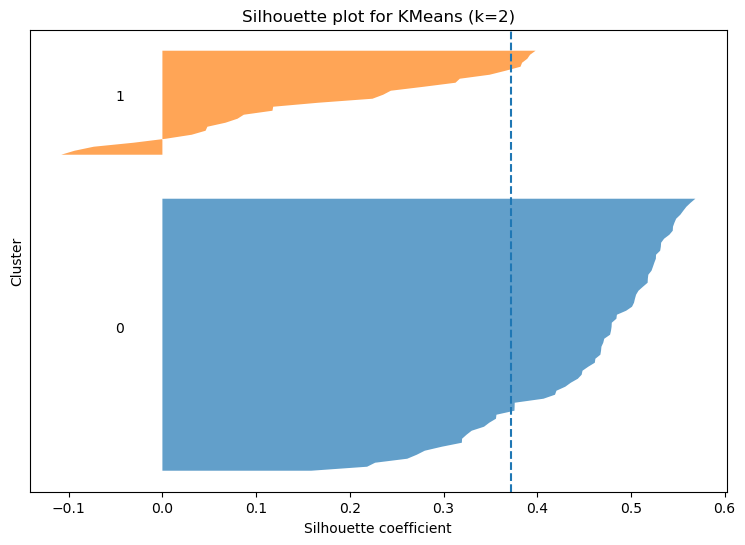

Cluster sizes


,cluster,n_neighborhoods
0,0,69
1,1,27


Cluster centroids in original feature space


,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1063.601,0.007,0.066,8.668,0.158,1.706,0.428,3.61,0.267,0.004,0.132,0.327,0.528,3.344,2.838,0.427,1.394,4.358,0.281,5.267,0.215,0.388,0.246,2096.995,463.756,1.235,0.111,0.21,3.563,1.325,0.087,1.852,4.027,2.931,2.839,0.0,2.438,0.520,1.626,0.568,1.480,0.239,13.739,0.221,9863.013,0.054,0.005,0.411,0.597,0.284,0.027,6.869,0.722,1062.550,691.349,299.484,775.427,586.913,880.843,385.185,306.050,813.198,282.207,510.242,957.510,586.309,1025.656,1440.414,1082.132,844.750,1094.917,1582.203,482.164,568.250,1195.025,1678.121,1910.699,2173.897,1543.248,1685.611,392.457,1394.949,1384.678,1891.590
1,1518.233,0.002,0.007,3.427,0.011,0.119,0.054,0.30,0.151,0.000,0.116,0.032,0.015,0.322,0.216,0.053,0.212,0.782,0.038,0.986,0.012,0.022,0.000,833.895,248.166,0.176,0.011,0.13,0.223,0.289,0.012,0.366,0.626,0.449,0.070,0.0,0.423,0.021,0.306,0.043,0.031,0.004,1.076,0.031,4550.880,0.038,0.001,0.029,0.686,0.401,0.027,3.737,0.981,3050.917,2122.529,615.949,2532.679,1699.301,2094.865,861.162,851.282,2358.674,960.523,1357.954,3715.368,1587.230,2840.157,3989.329,2803.710,1264.158,1354.928,4437.642,1582.353,2056.346,3873.564,4088.772,4737.569,4549.438,4362.911,2692.755,959.655,3896.047,3409.688,4184.842


Presentation-ready cluster profile


...

,long_term_avg_price_euro,accessibility_ratio,bouldering_spot_count_per_sq_km,bus_stop_count_per_sq_km,cinema_count_per_sq_km,dental_office_count_per_sq_km,diplomatic_mission_count_per_sq_km,doctor_count_per_sq_km,emergency_station_count_per_sq_km,exhibition_center_count_per_sq_km,fire_station_count_per_sq_km,food_market_count_per_sq_km,gallery_count_per_sq_km,gas_station_count_per_sq_km,gas_station_electric_count_per_sq_km,hospital_count_per_sq_km,hotel_count_per_sq_km,kindergarten_count_per_sq_km,library_count_per_sq_km,long_term_listing_count_per_sq_km,mall_count_per_sq_km,museum_count_per_sq_km,night_club_count_per_sq_km,parking_capacity_per_sq_km,parking_space_count_per_sq_km,pharmacy_count_per_sq_km,police_station_count_per_sq_km,pool_count_per_sq_km,public_artwork_count_per_sq_km,religious_institution_count_per_sq_km,research_institute_count_per_sq_km,school_count_per_sq_km,short_term_listing_count_per_sq_km,social_club_count_per_sq_km,spaeti_count_per_sq_km,stage_theater_count_per_sq_km,supermarket_count_per_sq_km,theater_count_per_sq_km,tram_stop_count_per_sq_km,transport_station_count_per_sq_km,transport_station_entrance_count_per_sq_km,university_count_per_sq_km,venue_count_per_sq_km,vocational_school_count_per_sq_km,bike_lane_length_m_per_sq_km,park_share,playground_share,milieuschutz_share,kindergarten_count_per_1000,school_count_per_1000,vocational_school_count_per_1000,kindergarten_capacity_per_1000,long_term_listing_count_per_1000,avg_dist_5_atm_m,avg_dist_5_bakery_m,avg_dist_5_bus_stop_m,avg_dist_3_dental_office_m,avg_dist_3_doctor_m,dist_1_hospital_m,avg_dist_3_kindergarten_m,avg_dist_3_park_m,avg_dist_5_pharmacy_m,avg_dist_3_playground_m,avg_dist_3_school_m,avg_dist_5_spaeti_m,avg_dist_5_supermarket_m,avg_dist_5_tram_stop_m,avg_dist_5_transport_station_m,avg_dist_3_bank_m,dist_1_emergency_station_m,dist_1_fire_station_m,avg_dist_3_food_market_m,avg_dist_3_gas_station_m,avg_dist_3_gas_station_electric_m,avg_dist_3_government_office_m,avg_dist_3_library_m,avg_dist_3_mall_m,avg_dist_3_petstore_m,dist_1_police_station_m,avg_dist_3_pool_m,avg_dist_3_recycling_point_m,avg_dist_3_transport_station_entrance_m,avg_dist_3_veterinary_clinic_m,avg_dist_3_vocational_school_m
cluster_kmeans_k2,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,-0.18,0.34,0.13,0.39,0.18,0.17,0.11,0.17,0.14,0.05,0.03,0.23,0.15,0.32,0.30,0.23,0.17,0.28,0.19,0.22,0.21,0.14,0.13,0.37,0.29,0.31,0.19,0.09,0.20,0.28,0.10,0.34,0.11,0.27,0.22,0,0.31,0.20,0.22,0.20,0.2,0.12,0.20,0.21,0.38,0.06,0.18,0.09,-0.08,-0.09,-0.01,0.11,-0.06,-0.46,-0.46,-0.32,-0.45,-0.39,-0.34,-0.37,-0.43,-0.45,-0.44,-0.40,-0.44,-0.42,-0.38,-0.49,-0.38,-0.19,-0.10,-0.46,-0.47,-0.48,-0.47,-0.44,-0.45,-0.37,-0.42,-0.26,-0.37,-0.42,-0.42,-0.37
1,0.46,-0.82,-0.32,-0.99,-0.46,-0.43,-0.28,-0.43,-0.36,-0.12,-0.07,-0.59,-0.38,-0.83,-0.77,-0.59,-0.43,-0.72,-0.48,-0.56,-0.55,-0.37,-0.34,-0.94,-0.75,-0.80,-0.47,-0.24,-0.51,-0.72,-0.25,-0.88,-0.28,-0.70,-0.57,0,-0.80,-0.52,-0.55,-0.52,-0.5,-0.31,-0.52,-0.53,-0.98,-0.18,-0.83,-0.22,0.21,0.24,-0.01,-0.28,0.15,1.17,1.19,0.83,1.14,0.98,0.88,0.95,1.10,1.16,1.12,1.03,1.13,1.08,0.96,1.26,0.96,0.48,0.27,1.18,1.20,1.22,1.20,1.12,1.14,0.95,1.08,0.66,0.94,1.08,1.06,0.94


Top distinguishing features per cluster


,feature,z_score_vs_city_avg,cluster,direction
0,bus_stop_count_per_sq_km,0.39,0,higher
1,bike_lane_length_m_per_sq_km,0.38,0,higher
2,parking_capacity_per_sq_km,0.37,0,higher
3,accessibility_ratio,0.34,0,higher
4,school_count_per_sq_km,0.34,0,higher
5,gas_station_count_per_sq_km,0.32,0,higher
6,supermarket_count_per_sq_km,0.31,0,higher
7,pharmacy_count_per_sq_km,0.31,0,higher
8,gas_station_electric_count_per_sq_km,0.30,0,higher
9,parking_space_count_per_sq_km,0.29,0,higher


Neighborhood membership by cluster


,neighborhood,district,cluster_kmeans_k2
0,Charlottenburg,Charlottenburg-Wilmersdorf,0
1,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0
2,Halensee,Charlottenburg-Wilmersdorf,0
3,Schmargendorf,Charlottenburg-Wilmersdorf,0
4,Westend,Charlottenburg-Wilmersdorf,0
5,Wilmersdorf,Charlottenburg-Wilmersdorf,0
6,Friedrichshain,Friedrichshain-Kreuzberg,0
7,Kreuzberg,Friedrichshain-Kreuzberg,0
8,Alt-Hohenschönhausen,Lichtenberg,0
9,Falkenberg,Lichtenberg,0


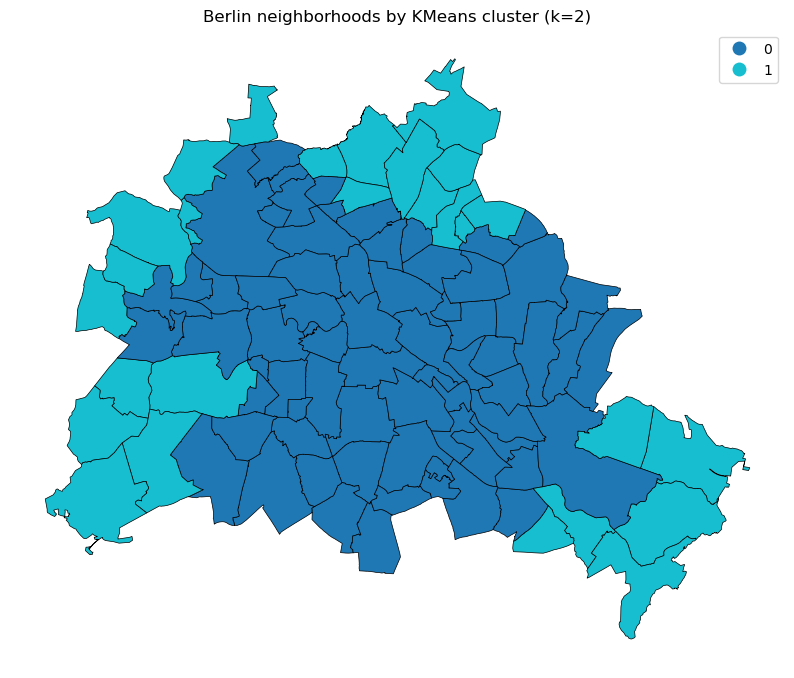

In [56]:
results_composite_k = interpret_kmeans_solution(
    df_input=df,
    X_matrix=X_composite,
    X_original=X_imputed,
    gdf_neighborhoods=gdf_neigh,
    feature_cols=feature_cols,
    selected_k=composite_k,
)

In [57]:
composite_preference_features = (
    group_feature_map["family"]
    + group_feature_map["transport"]
    + group_feature_map["nightlife"]
)

#### Interpreting the composite solution

The composite scenario combines three priorities:

- strong family orientation  
- good transport access  
- reduced emphasis on nightlife  

This produces a different clustering logic from the single-intent experiments. Instead of isolating one dominant dimension, the weighting balances multiple criteria at once.

The diagnostics show that the best solution is obtained at **k = 2**, with a silhouette score of approximately **0.37**. This is lower than the nightlife-only case, but clearly higher than the baseline `k = 3` solution. The result is therefore less sharply separated than a pure nightlife clustering, but still meaningful and interpretable.

At the selected composite weights and k = 2, the clustering produces:

- a large cluster of 69 neighborhoods  
- a smaller cluster of 27 neighborhoods  

The silhouette plot indicates reasonably clear separation, with the larger cluster showing stronger internal consistency and the smaller cluster containing the more distinctly separated peripheral areas.

This suggests that the composite preference profile does not carve out a small “ideal core” in the city. Instead, it separates:

- a broad set of neighborhoods that balance family and transport needs while avoiding strong nightlife concentration  
- a more peripheral set of neighborhoods that score worse on accessibility and family-supporting infrastructure  

Two distinct neighborhood types emerge:

- **Cluster 0: family- and transport-compatible urban neighborhoods**  
  This cluster performs better on the combined preference profile. It is characterized by:
  - better accessibility  
  - higher bus stop density  
  - stronger bike lane presence  
  - shorter distances to transport stations and everyday services  
  - stronger school-related infrastructure  
  - lower distances to schools and playgrounds  
  - relatively lower nightlife intensity than the nightlife-oriented core

  This cluster represents the best overall match for a user seeking family-friendliness, good transit, and less nightlife pressure.

- **Cluster 1: peripheral, lower-access neighborhoods**  
  This cluster contains outer and more weakly connected areas. It is characterized by:
  - lower transport density  
  - lower bike lane availability  
  - longer distances to schools, services, and transport nodes  
  - weaker overall accessibility  
  - lower service density and family-supporting infrastructure

  These neighborhoods are not necessarily undesirable in general, but they are less aligned with the specific composite preference profile tested here.

#### Best-matching cluster for the composite scenario

In [58]:
composite_cluster_scores, composite_best_cluster, _ = rank_clusters_for_preference(
    df_with_clusters=results_composite_k["df_result"],
    cluster_col=f"cluster_kmeans_k{composite_k}",
    X_original=X_imputed,
    preference_features=composite_preference_features,
)

Preference features used for scoring:


,feature
0,kindergarten_count_per_1000
1,school_count_per_1000
2,kindergarten_capacity_per_1000
3,playground_share
4,avg_dist_3_school_m
5,avg_dist_3_playground_m
6,bus_stop_count_per_sq_km
7,tram_stop_count_per_sq_km
8,transport_station_count_per_sq_km
9,transport_station_entrance_count_per_sq_km


Cluster ranking for this preference scenario:


cluster_kmeans_k2
0    0.253132
1   -0.646894
dtype: float64

Best-matching cluster: 0


The preference-based scoring confirms the interpretation above.

- **Cluster 0** achieves the highest score  
- **Cluster 1** scores clearly lower  

This indicates that the preferred neighborhoods form a broad and coherent part of the city rather than a narrow niche.

#### Comparison with the baseline clustering

In [59]:
df_compare = df.copy()

df_compare["cluster_base_k3"] = results_k3["df_result"]["cluster_kmeans_k3"]
df_compare["cluster_composite_k"] = results_composite_k["df_result"][f"cluster_kmeans_k{composite_k}"]

display(
    df_compare[
        ["neighborhood", "district", "cluster_base_k3", "cluster_composite_k"]
    ].sort_values(["cluster_base_k3", "cluster_composite_k", "district", "neighborhood"])
)

,neighborhood,district,cluster_base_k3,cluster_composite_k
1,Charlottenburg-Nord,Charlottenburg-Wilmersdorf,0,0
4,Schmargendorf,Charlottenburg-Wilmersdorf,0,0
5,Westend,Charlottenburg-Wilmersdorf,0,0
9,Alt-Hohenschönhausen,Lichtenberg,0,0
12,Friedrichsfelde,Lichtenberg,0,0
13,Karlshorst,Lichtenberg,0,0
14,Lichtenberg,Lichtenberg,0,0
16,Neu-Hohenschönhausen,Lichtenberg,0,0
17,Rummelsburg,Lichtenberg,0,0
19,Biesdorf,Marzahn-Hellersdorf,0,0


Compared with the baseline `k = 3` solution, the composite scenario does not create a completely new geography.

Instead, it selectively reshapes the baseline structure:

- many neighborhoods from the baseline intermediate and central-accessible groups remain in the preferred cluster  
- some peripheral neighborhoods remain clearly separated  
- a few boundary cases shift, especially where outer neighborhoods retain enough transport or family-related infrastructure to remain competitive

This is an important result. The composite weighting does not behave like a purely family or purely nightlife signal. It works as a **selective filter** on top of the broader urban structure.


#### Composite takeaway

The composite scenario is more realistic than any single-intent clustering, because real users rarely optimize for just one dimension.

In this case, the combined weighting does not isolate a compact central core, nor does it simply reproduce the family-oriented split. Instead, it identifies a broad set of neighborhoods that balance:

- accessibility  
- family-supporting infrastructure  
- lower nightlife intensity  

This makes the composite solution especially relevant from a recommendation perspective.

The composite experiment shows that user-intent weighting can move beyond one-dimensional clustering and approximate realistic trade-offs between preferences.

For a user seeking a family-friendly neighborhood with good transport access and less nightlife intensity, the model identifies a large and coherent set of neighborhoods that outperform the peripheral alternative.

This suggests that weighted clustering can serve as a useful intermediate layer between:

- a global citywide clustering  
- and a future recommendation system based on user-defined priorities